# FILE 1b — GENERIC CNN BACKBONE BENCHMARK (SIPaKMeD, 5-class)

Drop-in companion to `classifier-training-v3.ipynb`.

**What this does:** reproduces *exactly* Cell 8–12 of the main notebook (unified split →
CNN data pipeline → Stage-1 head training → Stage-2 fine-tune → 5-view TTA → metrics),
but the backbone is a **single configurable variable**. Run it once per architecture;
every run appends to the *same* output directory, so all probability tensors stay
row-aligned and can be fused later in a separate meta-ensemble notebook.

**Alignment guarantee**
* Split: `seed=1337`, `test=0.15`, `val=0.15`, stratified, drawn from the *same*
  `(canonical_class, filename_stem)` registry in the *same* sorted order as v3.
* Saved probabilities carry `test_keys` / `val_keys` so alignment is verifiable, not assumed.
* Cell `[VERIFY]` cross-checks against `pipeline_meta.json` from the v3 run when it is attached.

**How to run another model**
1. Run cells `[CFG]` → `[DATA]` **once** per session (they are model-independent).
2. Change `MODEL_NAME` in cell `[SELECT]`.
3. Re-run `[SELECT]` → `[ZIP]`. Nothing is overwritten; a new slug-prefixed set of
   artefacts is written and `reports/model_comparison.csv` is updated in place.

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [CFG] — IMPORTS, PATHS, HYPERPARAMETERS, BACKBONE ZOO
# Configuration is byte-for-byte identical to classifier-training-v3 where it
# affects the split or the optimisation schedule. Only the backbone varies.
# ════════════════════════════════════════════════════════════════════════════

import os, gc, json, math, glob, shutil, warnings, itertools
from collections import Counter

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)

from sklearn.model_selection    import train_test_split
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, cohen_kappa_score,
                                        balanced_accuracy_score, f1_score,
                                        precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from IPython.display            import FileLink, display

# ── PATHS ────────────────────────────────────────────────────────────────────
PNG_DIR    = '/kaggle/input/datasets/sazedkarim/pap-png/png'
OUTPUT_DIR = 'sipakmed_backbone_benchmark'

# Optional: point this at the v3 run's pipeline_meta.json (if attached as an input
# dataset) to HARD-VERIFY that this notebook reproduces the identical test split.
V3_META_PATH = 'sipakmed_unified_output/models/pipeline_meta.json'

# ── SPLIT / TRAINING CONSTANTS (do not change — alignment depends on these) ──
IMAGE_SIZE_DEFAULT = (224, 224)
NUM_CLASSES        = 5
SEED               = 1337
TEST_SIZE          = 0.15
VAL_SIZE           = 0.15

TRAIN_BATCH_SIZE   = 16
TTA_BATCH_SIZE     = 8
TTA_STEPS          = 5

STAGE1_EPOCHS      = 30
STAGE1_LR          = 1e-3
STAGE1_PATIENCE    = 7

STAGE2_EPOCHS      = 100
STAGE2_LR          = 1e-5
STAGE2_PATIENCE    = 10
RLROP_FACTOR       = 0.2
RLROP_PATIENCE     = 4
RLROP_MIN_LR       = 1e-7

# False  -> replicate v3 exactly (RandomFlip layers invoked with training=True,
#           i.e. each TTA view is stochastic).
# True   -> deterministic h-flip / v-flip views. Scientifically cleaner, but the
#           numbers are then not bit-comparable with the v3 VGG16/EffNetV2L rows.
DETERMINISTIC_TTA  = False

CANONICAL_CLASSES = [
    'Dyskeratotic', 'Koilocytotic', 'Metaplastic',
    'Parabasal', 'Superficial-Intermediate'
]
CLASS_TO_ID = {c: i for i, c in enumerate(CANONICAL_CLASSES)}

for d in [OUTPUT_DIR,
          f'{OUTPUT_DIR}/models',
          f'{OUTPUT_DIR}/probs',
          f'{OUTPUT_DIR}/plots',
          f'{OUTPUT_DIR}/reports']:
    os.makedirs(d, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── BACKBONE ZOO ─────────────────────────────────────────────────────────────
# Each entry:
#   builder        : callable(weights, input_shape) -> keras.Model (feature extractor)
#   preprocess     : the architecture's own preprocess_input (identity for the
#                    families that embed rescaling in the graph: EffNetV2,
#                    MobileNetV3, ConvNeXt)
#   img_size       : input resolution
#   ft_start_layer : Stage-2 unfreezes from this named layer onward (VGG family,
#                    where block boundaries are explicit and meaningful)
#   ft_fraction    : otherwise, unfreeze the top f of layers (BatchNorm always
#                    stays frozen — fine-tuning BN statistics on a 2.8k-image
#                    training set destabilises the running moments).
def _ident(x):
    return x

def _pp(module_name):
    mod = getattr(applications, module_name, None)
    return getattr(mod, 'preprocess_input', _ident) if mod is not None else _ident

MODEL_ZOO = {}

def _register(key, app_name, pp_module, slug=None, img_size=IMAGE_SIZE_DEFAULT,
              ft_start_layer=None, ft_fraction=0.50, builder_kwargs=None):
    """Only register architectures the installed Keras actually exposes."""
    app = getattr(applications, app_name, None)
    if app is None:
        return
    bk = builder_kwargs or {}
    MODEL_ZOO[key] = {
        'app_name'      : app_name,
        'slug'          : slug or key.lower().replace('-', '_'),
        'builder'       : (lambda weights, input_shape, _app=app, _bk=bk:
                           _app(include_top=False, weights=weights,
                                input_shape=input_shape, **_bk)),
        'preprocess'    : _pp(pp_module),
        'img_size'      : img_size,
        'ft_start_layer': ft_start_layer,
        'ft_fraction'   : ft_fraction,
    }

# --- baselines already reported in v3 (re-runnable here for sanity checking) --
_register('VGG16',             'VGG16',             'vgg16', ft_start_layer='block3_conv1')
_register('VGG19',             'VGG19',             'vgg19', ft_start_layer='block3_conv1')
_register('EfficientNetV2L',   'EfficientNetV2L',   'efficientnet_v2')
# --- ResNet family -----------------------------------------------------------
_register('ResNet50',          'ResNet50',          'resnet')
# _register('ResNet101',         'ResNet101',         'resnet')
_register('ResNet50V2',        'ResNet50V2',        'resnet_v2')
# _register('ResNet101V2',       'ResNet101V2',       'resnet_v2')
# _register('ResNet152V2',       'ResNet152V2',       'resnet_v2')
# --- Inception / Xception ----------------------------------------------------
_register('InceptionV3',       'InceptionV3',       'inception_v3')
_register('InceptionResNetV2', 'InceptionResNetV2', 'inception_resnet_v2')
_register('Xception',          'Xception',          'xception')
# --- DenseNet ----------------------------------------------------------------
# _register('DenseNet121',       'DenseNet121',       'densenet')
# _register('DenseNet169',       'DenseNet169',       'densenet')
# _register('DenseNet201',       'DenseNet201',       'densenet')
# --- EfficientNet v1 / v2 ----------------------------------------------------
# _register('EfficientNetB0',    'EfficientNetB0',    'efficientnet')
# _register('EfficientNetB1',    'EfficientNetB1',    'efficientnet')
# _register('EfficientNetB2',    'EfficientNetB2',    'efficientnet')
# _register('EfficientNetB3',    'EfficientNetB3',    'efficientnet')
# _register('EfficientNetV2S',   'EfficientNetV2S',   'efficientnet_v2')
_register('EfficientNetV2M',   'EfficientNetV2M',   'efficientnet_v2')
# --- Mobile / lightweight ----------------------------------------------------
_register('MobileNetV2',       'MobileNetV2',       'mobilenet_v2')
# _register('MobileNetV3Large',  'MobileNetV3Large',  'mobilenet_v3')
_register('NASNetMobile',      'NASNetMobile',      'nasnet')
# --- ConvNeXt (modern CNN baseline; preprocessing is internal) ---------------
# _register('ConvNeXtTiny',      'ConvNeXtTiny',      'convnext')
# _register('ConvNeXtSmall',     'ConvNeXtSmall',     'convnext')
# _register('ConvNeXtBase',      'ConvNeXtBase',      'convnext')
# --- RegNet ------------------------------------------------------------------
_register('RegNetY032',        'RegNetY032',        'regnet')
_register('RegNetX032',        'RegNetX032',        'regnet')

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')
print(f'Split      : test={TEST_SIZE}  val={VAL_SIZE}  seed={SEED}  (UNIFIED)')
print(f'Output dir : {OUTPUT_DIR}')
print(f'\nBackbones available in this environment ({len(MODEL_ZOO)}):')
for i, k in enumerate(sorted(MODEL_ZOO), 1):
    print(f'  {i:2d}. {k}')
print('\n✅ Configuration complete.')

TensorFlow : 2.20.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Split      : test=0.15  val=0.15  seed=1337  (UNIFIED)
Output dir : sipakmed_backbone_benchmark

Backbones available in this environment (11):
   1. EfficientNetV2L
   2. EfficientNetV2M
   3. InceptionResNetV2
   4. InceptionV3
   5. MobileNetV2
   6. NASNetMobile
   7. ResNet50
   8. ResNet50V2
   9. VGG16
  10. VGG19
  11. Xception

✅ Configuration complete.


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [DATA-1] — IDENTITY HELPERS + RAW PNG LOAD
# Mirrors v3 Cell 4. Images are loaded ONCE and cached in RAM; switching
# backbones later does not require re-reading the corpus.
# ════════════════════════════════════════════════════════════════════════════

def _canonical_name(folder_name):
    """'4_im_Superficial-Intermediate' -> 'Superficial-Intermediate'"""
    parts = folder_name.split('_im_')
    return parts[-1] if len(parts) > 1 else folder_name

def _stem(path_or_name):
    """Filename without directory or extension. '025_01.png' -> '025_01'"""
    return os.path.splitext(os.path.basename(path_or_name))[0]

print(f'Loading PNG dataset from: {PNG_DIR}')
full_ds_unbatched = tf.keras.utils.image_dataset_from_directory(
    PNG_DIR, label_mode='int', image_size=IMAGE_SIZE_DEFAULT,
    batch_size=None, seed=SEED, shuffle=False
)
png_folder_names = full_ds_unbatched.class_names
png_file_paths   = list(full_ds_unbatched.file_paths)   # order == iteration order
assert set(_canonical_name(c) for c in png_folder_names) == set(CANONICAL_CLASSES)

all_images_list = []
for img, lbl in full_ds_unbatched:
    all_images_list.append(img.numpy().astype(np.uint8))

# Composite identity key — the stem alone is NOT unique across class folders.
png_keys = [(_canonical_name(os.path.basename(os.path.dirname(p))), _stem(p))
            for p in png_file_paths]

assert len(png_keys) == len(all_images_list) == len(png_file_paths)
assert len(set(png_keys)) == len(png_keys), 'Duplicate (class, stem) in PNG tree.'
print(f'PNG images loaded : {len(all_images_list)}')
print(f'Unique stems      : {len(set(k[1] for k in png_keys))}  '
      f'(vs {len(png_keys)} images -> composite key required)')

Loading PNG dataset from: /kaggle/input/datasets/sazedkarim/pap-png/png
Found 4049 files belonging to 5 classes.


I0000 00:00:1791125438.796496      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791125438.800381      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


PNG images loaded : 4049
Unique stems      : 1860  (vs 4049 images -> composite key required)


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [DATA-2] — UNIFIED REGISTRY & SINGLE STRATIFIED SPLIT
#
# Reproduces v3 Cell 5 exactly. In v3 the registry was
#     common_keys = sorted(set(morph_keys) & set(png_keys))
# and the morphological pipeline reported ZERO segmentation failures over all
# 4049 images, so that intersection is the full PNG key set. Sorting the PNG
# keys therefore yields the identical ordering, hence identical train/val/test
# index sets under the same seed and stratification vector. Cell [VERIFY]
# checks this empirically rather than taking it on faith.
# ════════════════════════════════════════════════════════════════════════════

png_key2row  = {k: i for i, k in enumerate(png_keys)}
common_keys  = sorted(set(png_key2row))
n_common     = len(common_keys)

y_unified = np.array([CLASS_TO_ID[k[0]] for k in common_keys], dtype=np.int64)

reg_idx = np.arange(n_common)
idx_tv, idx_test = train_test_split(
    reg_idx, test_size=TEST_SIZE, random_state=SEED, stratify=y_unified)
_val_ratio_adj = VAL_SIZE / (1.0 - TEST_SIZE)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=_val_ratio_adj, random_state=SEED, stratify=y_unified[idx_tv])

SPLIT = {'train': idx_train, 'val': idx_val, 'test': idx_test}
print(f'Unified registry  : {n_common}')
for name, idx in SPLIT.items():
    dist = Counter(y_unified[idx])
    print(f'{name:>5}: {len(idx):>5}  ' +
          '  '.join(f'{CANONICAL_CLASSES[c][:6]}={dist[c]}' for c in range(NUM_CLASSES)))

# Disjointness guards
assert len(set(idx_train) & set(idx_val))  == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val)   & set(idx_test)) == 0
assert len(idx_train) + len(idx_val) + len(idx_test) == n_common

png_rows   = np.array([png_key2row[k] for k in common_keys])
test_keys  = [common_keys[i] for i in idx_test]
val_keys   = [common_keys[i] for i in idx_val]
train_keys = [common_keys[i] for i in idx_train]

test_filenames  = [f'{c}/{s}' for c, s in test_keys]    # collision-safe identifier
val_filenames   = [f'{c}/{s}' for c, s in val_keys]
train_filenames = [f'{c}/{s}' for c, s in train_keys]

# Exact per-class split composition (thesis Table 3.2)
split_tbl = pd.DataFrame({
    'Train': pd.Series(y_unified[idx_train]).value_counts().sort_index(),
    'Val'  : pd.Series(y_unified[idx_val]).value_counts().sort_index(),
    'Test' : pd.Series(y_unified[idx_test]).value_counts().sort_index(),
})
split_tbl.index = [CANONICAL_CLASSES[i] for i in split_tbl.index]
split_tbl['Total'] = split_tbl.sum(axis=1)
split_tbl.loc['TOTAL'] = split_tbl.sum()
print('\n-- Unified stratified partition --')
print(split_tbl.to_string())
split_tbl.to_csv(f'{OUTPUT_DIR}/reports/split_composition.csv')

with open(f'{OUTPUT_DIR}/reports/split_keys.json', 'w') as f:
    json.dump({'seed': SEED, 'test_size': TEST_SIZE, 'val_size': VAL_SIZE,
               'canonical_classes': CANONICAL_CLASSES,
               'train_keys': train_filenames,
               'val_keys'  : val_filenames,
               'test_keys' : test_filenames}, f, indent=2)
print('\n✅ Unified split ready.')

Unified registry  : 4049
train:  2833  Dysker=569  Koiloc=577  Metapl=555  Paraba=551  Superf=581
  val:   608  Dysker=122  Koiloc=124  Metapl=119  Paraba=118  Superf=125
 test:   608  Dysker=122  Koiloc=124  Metapl=119  Paraba=118  Superf=125

-- Unified stratified partition --
                          Train  Val  Test  Total
Dyskeratotic                569  122   122    813
Koilocytotic                577  124   124    825
Metaplastic                 555  119   119    793
Parabasal                   551  118   118    787
Superficial-Intermediate    581  125   125    831
TOTAL                      2833  608   608   4049

✅ Unified split ready.


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [VERIFY] — HARD ALIGNMENT CHECK AGAINST THE v3 RUN  (optional)
#
# If pipeline_meta.json from classifier-training-v3 is reachable, assert that the
# test partition here is IDENTICAL — same samples, same order. Without this the
# downstream meta-ensemble would silently fuse mis-registered rows, which inflates
# or deflates fused accuracy for reasons unrelated to model complementarity.
# ════════════════════════════════════════════════════════════════════════════

_v3_candidates = [V3_META_PATH] + glob.glob(
    '/kaggle/input/**/pipeline_meta.json', recursive=True)

_verified = False
for _p in _v3_candidates:
    if not os.path.exists(_p):
        continue
    with open(_p) as f:
        _v3 = json.load(f)
    _v3_test = _v3.get('test_filenames')
    if not _v3_test:
        continue
    same_set   = set(_v3_test) == set(test_filenames)
    same_order = list(_v3_test) == list(test_filenames)
    print(f'Found v3 meta: {_p}')
    print(f'   n_test v3={len(_v3_test)}  here={len(test_filenames)}')
    print(f'   identical SET   : {same_set}')
    print(f'   identical ORDER : {same_order}')
    if same_order:
        print('   ✅ Row-for-row aligned with v3 probability tensors — safe to meta-ensemble.')
        _verified = True
    elif same_set:
        print('   ⚠️  Same samples, DIFFERENT order. Reindex v3 tensors by test_keys before fusing.')
    else:
        print('   ❌ Test sets differ. DO NOT fuse these probabilities with the v3 tensors.')
    break

if not _verified:
    print('(No v3 pipeline_meta.json found, or order differs. '
          'Alignment is still fully recoverable: every saved .npz carries test_keys.)')

(No v3 pipeline_meta.json found, or order differs. Alignment is still fully recoverable: every saved .npz carries test_keys.)


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [DATA-3] — ARRAY MATERIALISATION, AUGMENTATION, TTA
# Mirrors v3 Cell 8. Labels come from CLASS_TO_ID, never from the directory
# iteration order, so folder renaming can never silently permute the class axis.
# ════════════════════════════════════════════════════════════════════════════

if 'all_images_list' not in globals():
    raise RuntimeError('The image cache was freed by a previous run of this cell. '
                       'Re-run cell [DATA-1] (and [DATA-2]) before re-running this one.')

def _gather(split_name):
    reg  = SPLIT[split_name]
    imgs = np.stack([all_images_list[png_rows[i]] for i in reg]).astype(np.float32)
    lbls = y_unified[reg]
    return imgs, lbls

train_imgs, train_lbls = _gather('train')
val_imgs,   val_lbls   = _gather('val')
test_imgs,  test_lbls  = _gather('test')

y_test_true = test_lbls.copy()
y_val_true  = val_lbls.copy()

print(f'CNN   train={train_imgs.shape} val={val_imgs.shape} test={test_imgs.shape}')

# Free the uint8 corpus — the three float32 split arrays are the only copies
# needed from here on. Guarded so that re-running this cell is not fatal.
if 'all_images_list' in globals():
    del all_images_list
    gc.collect()

cw      = compute_class_weight('balanced', classes=np.unique(train_lbls), y=train_lbls)
cw_dict = dict(enumerate(cw))
print(f'Class weights: { {k: round(v,4) for k,v in cw_dict.items()} }')

AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='shared_augmentation')

def make_tf_dataset(images, labels, batch_size, shuffle=False, augment=False,
                    resize_to=None):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if resize_to is not None and tuple(resize_to) != tuple(IMAGE_SIZE_DEFAULT):
        ds = ds.map(lambda x, y: (tf.image.resize(x, resize_to), y),
                    num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=SEED)
    if augment:
        def _aug(x, y):
            x = data_augmentation(tf.expand_dims(x, 0), training=True)[0]
            return x, y
        ds = ds.map(_aug, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

tta_fh   = layers.RandomFlip('horizontal')
tta_fv   = layers.RandomFlip('vertical')
tta_r90  = lambda x: tf.image.rot90(x, k=1)
tta_r270 = lambda x: tf.image.rot90(x, k=3)

def tta_predict(model, dataset):
    """5-view TTA: identity + h-flip + v-flip + rot90 + rot270, averaged.
    Dataset MUST be unshuffled so output rows align with registry order."""
    out = []
    for images, _ in dataset:
        p  = model.predict(images, verbose=0)
        if DETERMINISTIC_TTA:
            p += model.predict(tf.image.flip_left_right(images), verbose=0)
            p += model.predict(tf.image.flip_up_down(images),    verbose=0)
        else:
            p += model.predict(tta_fh(images, training=True), verbose=0)
            p += model.predict(tta_fv(images, training=True), verbose=0)
        p += model.predict(tta_r90(images),  verbose=0)
        p += model.predict(tta_r270(images), verbose=0)
        out.extend(p / TTA_STEPS)
    return np.asarray(out)

print('✅ CNN data pipeline ready (model-independent — no need to re-run per backbone).')

CNN   train=(2833, 224, 224, 3) val=(608, 224, 224, 3) test=(608, 224, 224, 3)
Class weights: {0: np.float64(0.9958), 1: np.float64(0.982), 2: np.float64(1.0209), 3: np.float64(1.0283), 4: np.float64(0.9752)}
✅ CNN data pipeline ready (model-independent — no need to re-run per backbone).




########################################################################
#  [1/11]  EfficientNetV2L
########################################################################
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

EfficientNetV2L  |  input (224, 224)  |  params 118,543,525
-- EfficientNetV2L Stage 1: head training --
Epoch 1/30


2026-10-04 14:52:10.286791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:52:10.421354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:52:11.286010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:52:11.426555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:52:12.320986: E external/local_xla/xla/stream_

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.5991 - loss: 1.1461

2026-10-04 14:53:35.716628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:53:35.847722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:53:36.730468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:53:36.865356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 14:53:37.705328: E external/local_xla/xla/stream_

178/178 ━━━━━━━━━━━━━━━━━━━━ 205s 592ms/step - accuracy: 0.6858 - loss: 0.9063 - val_accuracy: 0.8224 - val_loss: 0.5815
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 275ms/step - accuracy: 0.7561 - loss: 0.6777 - val_accuracy: 0.8487 - val_loss: 0.4021
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 48s 271ms/step - accuracy: 0.7776 - loss: 0.6113 - val_accuracy: 0.8684 - val_loss: 0.3642
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 272ms/step - accuracy: 0.7910 - loss: 0.5696 - val_accuracy: 0.8832 - val_loss: 0.3068
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 48s 271ms/step - accuracy: 0.7956 - loss: 0.5446 - val_accuracy: 0.9062 - val_loss: 0.2648
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 44s 248ms/step - accuracy: 0.7981 - loss: 0.5243 - val_accuracy: 0.8898 - val_loss: 0.3090
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.8168 - loss: 0.5095 - val_accuracy: 0.9013 - val_loss: 0.2745
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.8302 - loss: 0.4707 - va

...

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8739 - loss: 0.3296

2026-10-04 15:17:23.685405: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:17:23.824769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:17:23.966467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:17:24.106264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:17:24.376980: E external/local_xla/xla/stream_

178/178 ━━━━━━━━━━━━━━━━━━━━ 286s 850ms/step - accuracy: 0.8870 - loss: 0.2951 - val_accuracy: 0.9572 - val_loss: 0.1319 - learning_rate: 1.0000e-05
Epoch 28/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 420ms/step - accuracy: 0.9139 - loss: 0.2365 - val_accuracy: 0.9490 - val_loss: 0.1524 - learning_rate: 1.0000e-05
Epoch 29/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 453ms/step - accuracy: 0.9298 - loss: 0.2012 - val_accuracy: 0.9638 - val_loss: 0.1046 - learning_rate: 1.0000e-05
Epoch 30/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 418ms/step - accuracy: 0.9400 - loss: 0.1710 - val_accuracy: 0.9638 - val_loss: 0.1161 - learning_rate: 1.0000e-05
Epoch 31/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 74s 416ms/step - accuracy: 0.9471 - loss: 0.1535 - val_accuracy: 0.9622 - val_loss: 0.1160 - learning_rate: 1.0000e-05
Epoch 32/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 80s 451ms/step - accuracy: 0.9538 - loss: 0.1461 - val_accuracy: 0.9638 - val_loss: 0.0903 - learning_rate: 1.0000e-05
Epoch 33/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 74s 

2026-10-04 15:48:59.552261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:48:59.687024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:49:00.558695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:49:00.700185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:49:01.574247: E external/local_xla/xla/stream_

  Val TTA 97.53%  |  Test TTA 97.37% [96.05, 98.52]  |  no-TTA 96.88% (+0.49 pp)
  BalAcc 97.35%  kappa 0.9671  macroF1 0.9740  ECE 0.0090  abnormal→normal 2/246
                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    0.9508    0.9748       122
            Koilocytotic     0.9167    0.9758    0.9453       124
             Metaplastic     0.9826    0.9496    0.9658       119
               Parabasal     1.0000    0.9915    0.9957       118
Superficial-Intermediate     0.9766    1.0000    0.9881       125

                accuracy                         0.9737       608
               macro avg     0.9752    0.9735    0.9740       608
            weighted avg     0.9748    0.9737    0.9738       608



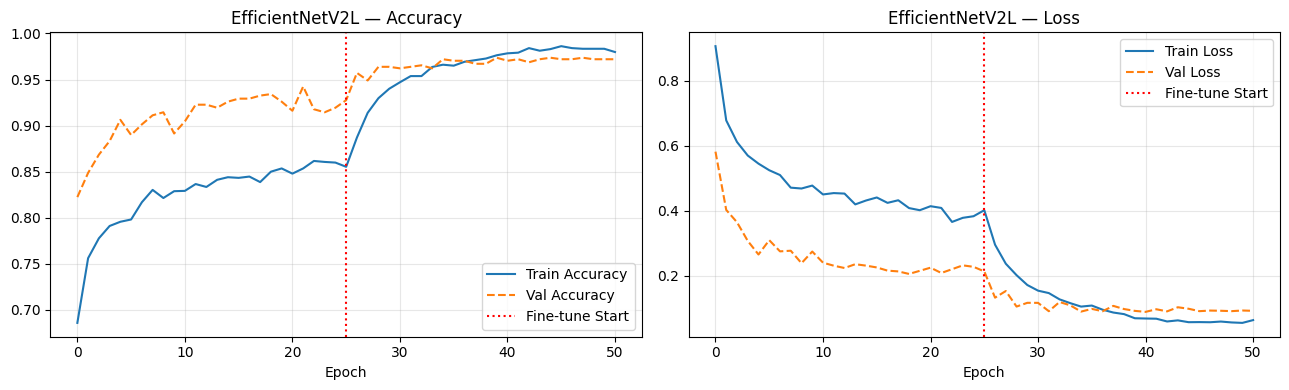

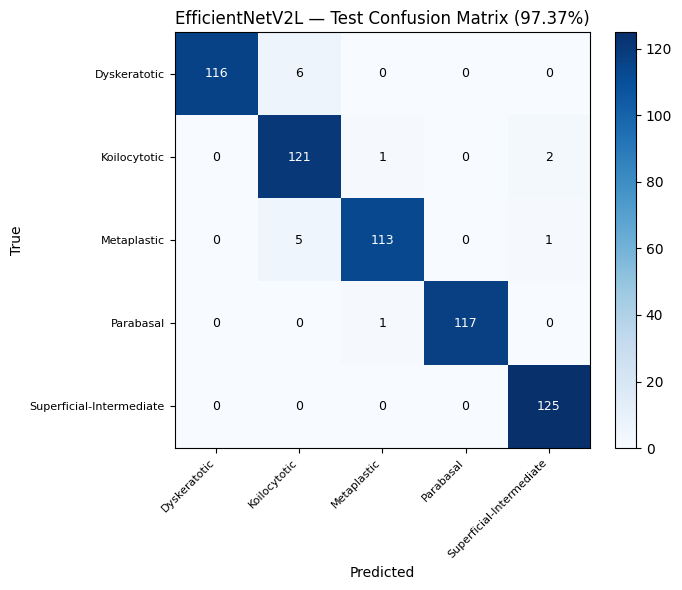

✅ EfficientNetV2L done in 60.8 min — Test 97.37%


########################################################################
#  [2/11]  EfficientNetV2M
########################################################################
214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

EfficientNetV2M  |  input (224, 224)  |  params 53,947,065
-- EfficientNetV2M Stage 1: head training --
Epoch 1/30


2026-10-04 15:54:09.990811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:54:10.124432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:54:10.979862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:54:11.117770: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:54:11.967502: E external/local_xla/xla/stream_

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5795 - loss: 1.1966

2026-10-04 15:55:12.496884: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:55:12.630708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:55:13.450944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:55:13.586162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 15:55:15.039747: E external/local_xla/xla/stream_

178/178 ━━━━━━━━━━━━━━━━━━━━ 154s 455ms/step - accuracy: 0.6650 - loss: 0.9691 - val_accuracy: 0.8520 - val_loss: 0.5475
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.7515 - loss: 0.7007 - val_accuracy: 0.8421 - val_loss: 0.4245
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.7691 - loss: 0.6169 - val_accuracy: 0.8816 - val_loss: 0.3260
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.7794 - loss: 0.5969 - val_accuracy: 0.8832 - val_loss: 0.3140
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.7921 - loss: 0.5622 - val_accuracy: 0.8914 - val_loss: 0.3063
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.8164 - loss: 0.5067 - val_accuracy: 0.8997 - val_loss: 0.2803
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.8108 - loss: 0.5240 - val_accuracy: 0.9062 - val_loss: 0.2639
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.8104 - loss: 0.5170 - va

...

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8760 - loss: 0.3391

2026-10-04 16:12:35.342665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:12:35.477818: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:12:35.763649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:12:35.898623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


178/178 ━━━━━━━━━━━━━━━━━━━━ 206s 587ms/step - accuracy: 0.8846 - loss: 0.3198 - val_accuracy: 0.9375 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 32/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 46s 258ms/step - accuracy: 0.9096 - loss: 0.2500 - val_accuracy: 0.9539 - val_loss: 0.1309 - learning_rate: 1.0000e-05
Epoch 33/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 45s 251ms/step - accuracy: 0.9206 - loss: 0.2196 - val_accuracy: 0.9490 - val_loss: 0.1235 - learning_rate: 1.0000e-05
Epoch 34/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.9354 - loss: 0.1933 - val_accuracy: 0.9523 - val_loss: 0.1287 - learning_rate: 1.0000e-05
Epoch 35/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 45s 251ms/step - accuracy: 0.9340 - loss: 0.1780 - val_accuracy: 0.9589 - val_loss: 0.1034 - learning_rate: 1.0000e-05
Epoch 36/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.9382 - loss: 0.1767 - val_accuracy: 0.9638 - val_loss: 0.1079 - learning_rate: 1.0000e-05
Epoch 37/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 

2026-10-04 16:33:33.180942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:33:33.313854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:33:34.191142: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:33:34.328834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 16:33:35.141948: E external/local_xla/xla/stream_

  Val TTA 96.88%  |  Test TTA 96.71% [95.23, 98.03]  |  no-TTA 96.88% (-0.16 pp)
  BalAcc 96.72%  kappa 0.9589  macroF1 0.9674  ECE 0.0072  abnormal→normal 1/246
                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    0.8934    0.9437       122
            Koilocytotic     0.8889    0.9677    0.9266       124
             Metaplastic     0.9669    0.9832    0.9750       119
               Parabasal     1.0000    0.9915    0.9957       118
Superficial-Intermediate     0.9921    1.0000    0.9960       125

                accuracy                         0.9671       608
               macro avg     0.9696    0.9672    0.9674       608
            weighted avg     0.9692    0.9671    0.9672       608



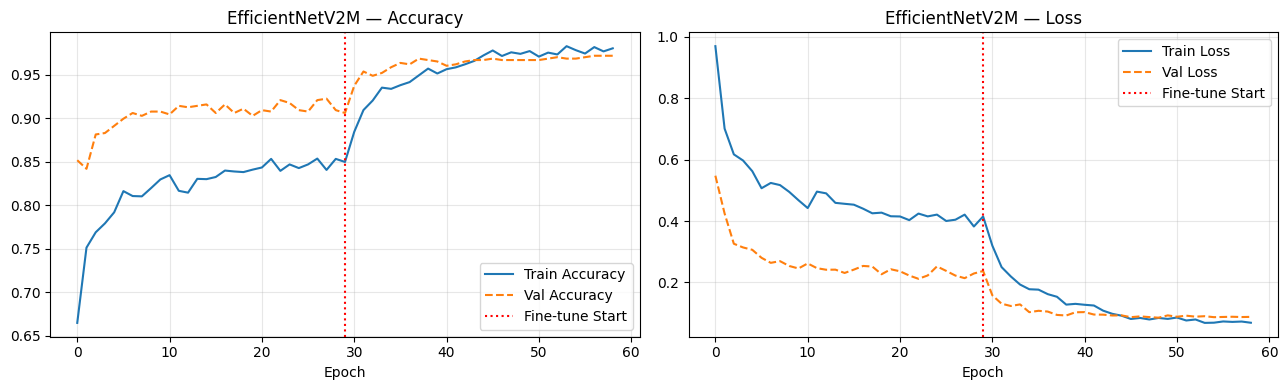

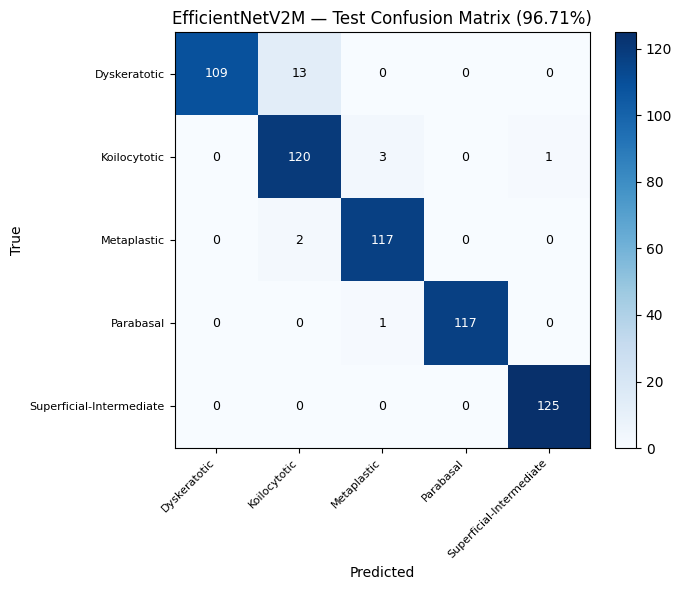

✅ EfficientNetV2M done in 42.4 min — Test 96.71%


########################################################################
#  [3/11]  InceptionResNetV2
########################################################################
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

InceptionResNetV2  |  input (224, 224)  |  params 55,265,509
-- InceptionResNetV2 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 90s 309ms/step - accuracy: 0.7084 - loss: 0.8412 - val_accuracy: 0.8520 - val_loss: 0.3873
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.7967 - loss: 0.5860 - val_accuracy: 0.8618 - val_loss: 0.3675
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.8073 - loss: 0.5262 - val_accuracy: 0.8717 - val_loss: 0.3613
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.8175 - loss: 0.4934 - val_accuracy: 0.8668 - val_loss: 0.3483
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.8140 - loss: 0.4958

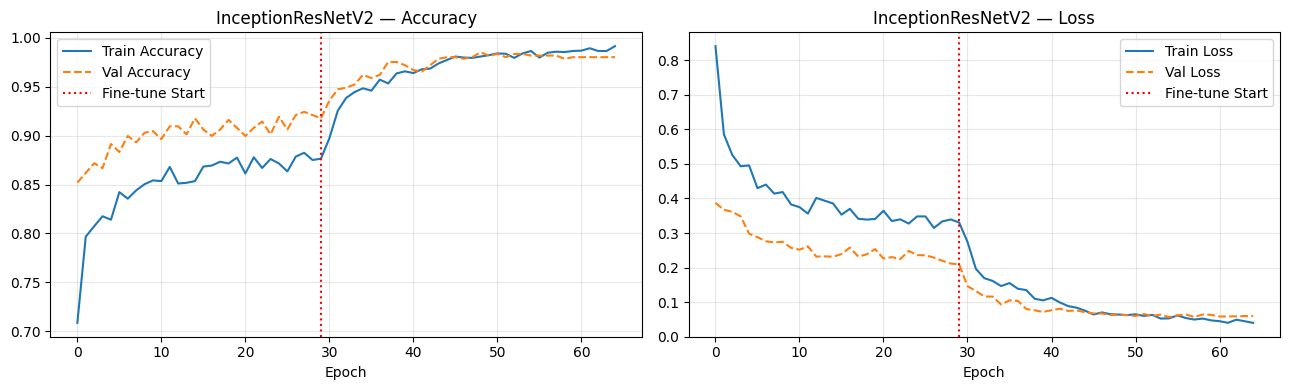

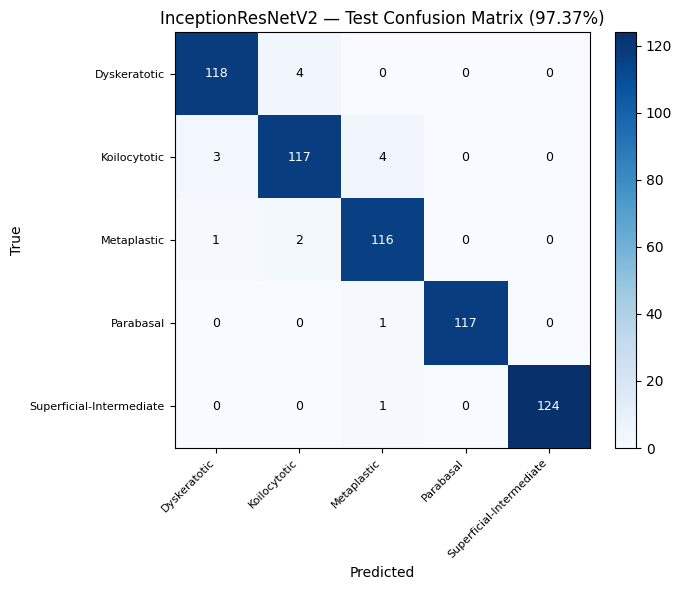

✅ InceptionResNetV2 done in 45.0 min — Test 97.37%


########################################################################
#  [4/11]  InceptionV3
########################################################################
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

InceptionV3  |  input (224, 224)  |  params 22,995,749
-- InceptionV3 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 57s 202ms/step - accuracy: 0.7123 - loss: 0.8584 - val_accuracy: 0.7780 - val_loss: 0.5753
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.7836 - loss: 0.6376 - val_accuracy: 0.8602 - val_loss: 0.3809
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - accuracy: 0.8090 - loss: 0.5375 - val_accuracy: 0.8651 - val_loss: 0.3660
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.8041 - loss: 0.5326 - val_accuracy: 0.8832 - val_loss: 0.3261
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.8048 - loss: 0.5081 - val_accuracy: 0

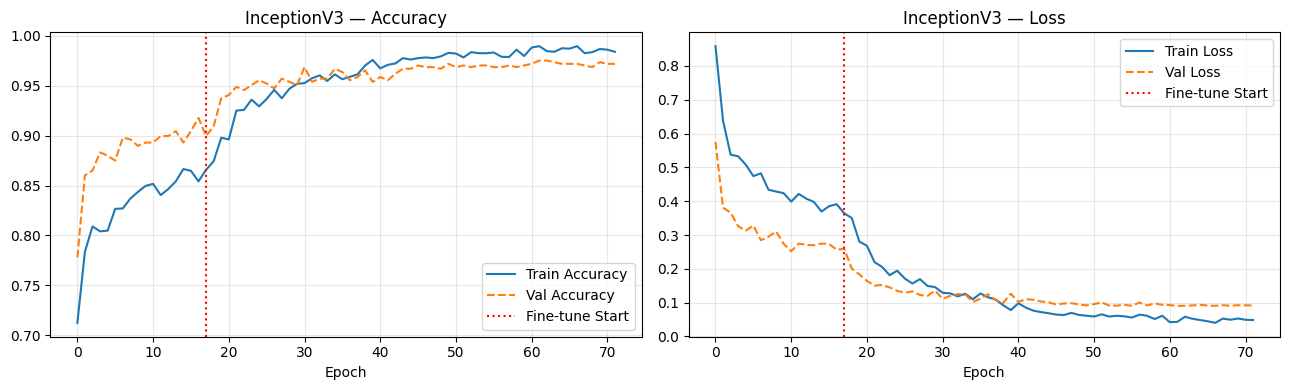

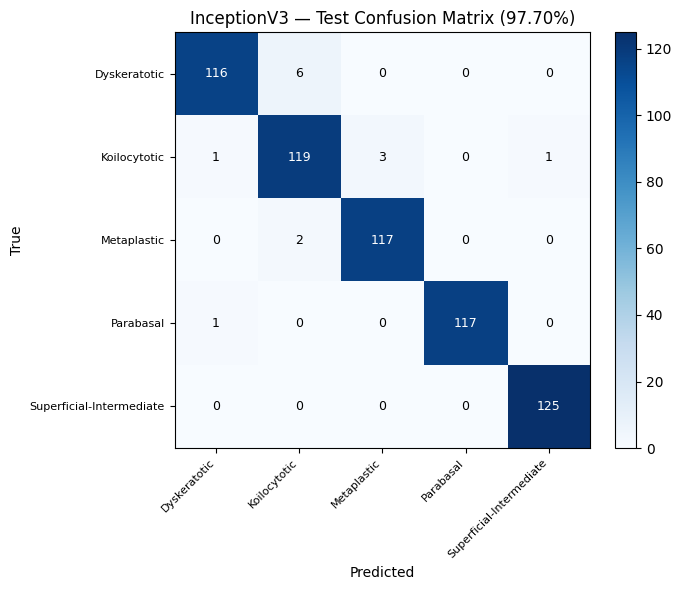

✅ InceptionV3 done in 32.1 min — Test 97.70%


########################################################################
#  [5/11]  MobileNetV2
########################################################################
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MobileNetV2  |  input (224, 224)  |  params 3,054,661
-- MobileNetV2 Stage 1: head training --
Epoch 1/30


2026-10-04 18:01:37.145439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 18:01:37.282663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7134 - loss: 0.8898

2026-10-04 18:02:03.465325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 18:02:03.599370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


178/178 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.7617 - loss: 0.7331 - val_accuracy: 0.8783 - val_loss: 0.3500
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.8327 - loss: 0.4840 - val_accuracy: 0.8750 - val_loss: 0.3139
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8496 - loss: 0.4352 - val_accuracy: 0.8882 - val_loss: 0.2796
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.8486 - loss: 0.4364 - val_accuracy: 0.8980 - val_loss: 0.2806
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8648 - loss: 0.3632 - val_accuracy: 0.9095 - val_loss: 0.2354
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.8705 - loss: 0.3510 - val_accuracy: 0.9145 - val_loss: 0.2352
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.8645 - loss: 0.3681 - val_accuracy: 0.9112 - val_loss: 0.2469
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.8676 - loss: 0.3553 - val_accura

2026-10-04 18:21:32.376123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 18:21:32.530954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 18:21:32.667489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Val TTA 96.22%  |  Test TTA 97.20% [95.72, 98.52]  |  no-TTA 96.71% (+0.49 pp)
  BalAcc 97.20%  kappa 0.9650  macroF1 0.9723  ECE 0.0194  abnormal→normal 1/246
                          precision    recall  f1-score   support

            Dyskeratotic     0.9914    0.9426    0.9664       122
            Koilocytotic     0.9154    0.9597    0.9370       124
             Metaplastic     0.9664    0.9664    0.9664       119
               Parabasal     1.0000    0.9915    0.9957       118
Superficial-Intermediate     0.9921    1.0000    0.9960       125

                accuracy                         0.9720       608
               macro avg     0.9730    0.9720    0.9723       608
            weighted avg     0.9728    0.9720    0.9722       608



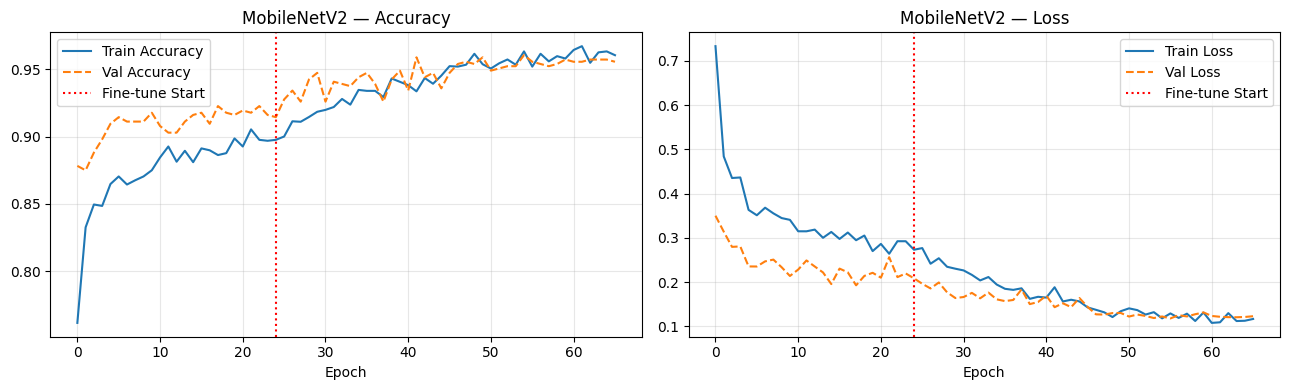

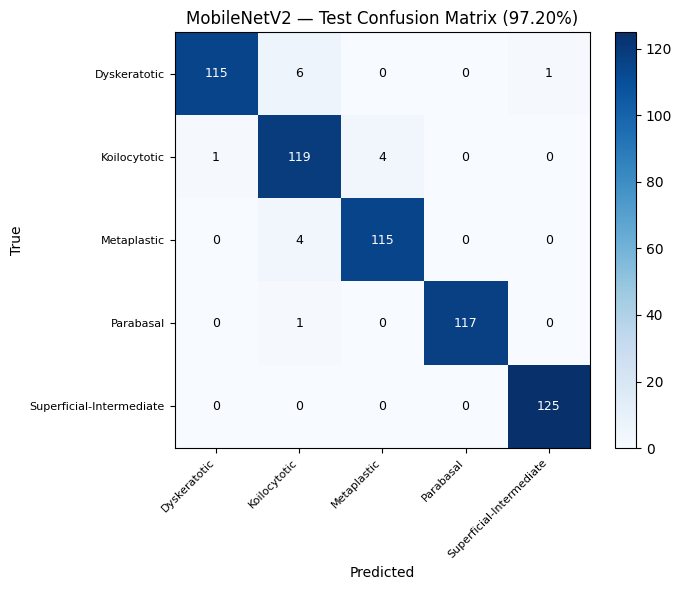

✅ MobileNetV2 done in 21.8 min — Test 97.20%


########################################################################
#  [6/11]  NASNetMobile
########################################################################
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

NASNetMobile  |  input (224, 224)  |  params 4,950,809
-- NASNetMobile Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.7021 - loss: 0.8630 - val_accuracy: 0.8553 - val_loss: 0.4275
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.7812 - loss: 0.6123 - val_accuracy: 0.8553 - val_loss: 0.3938
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.8066 - loss: 0.5454 - val_accuracy: 0.8717 - val_loss: 0.3208
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.8112 - loss: 0.5061 - val_accuracy: 0.8914 - val_loss: 0.3158
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.8175 - loss: 0.4826 - val_accuracy: 0.87

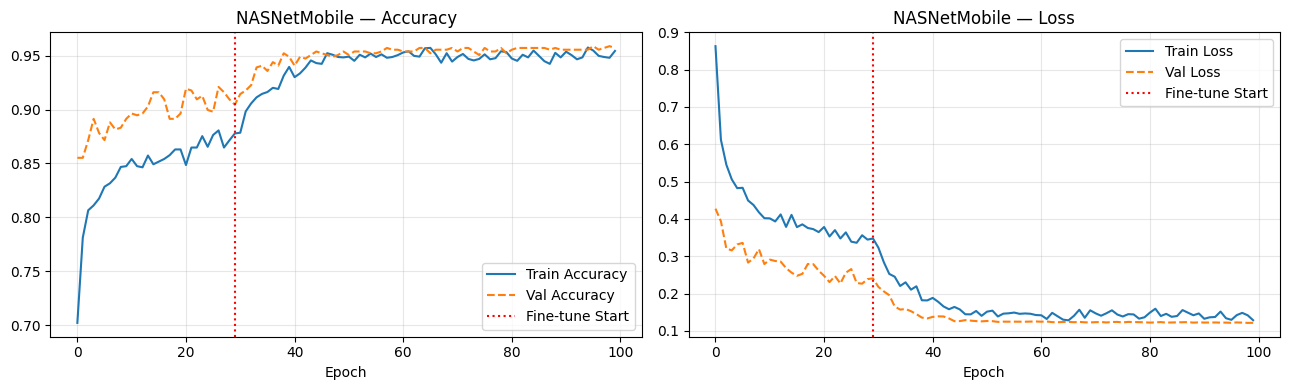

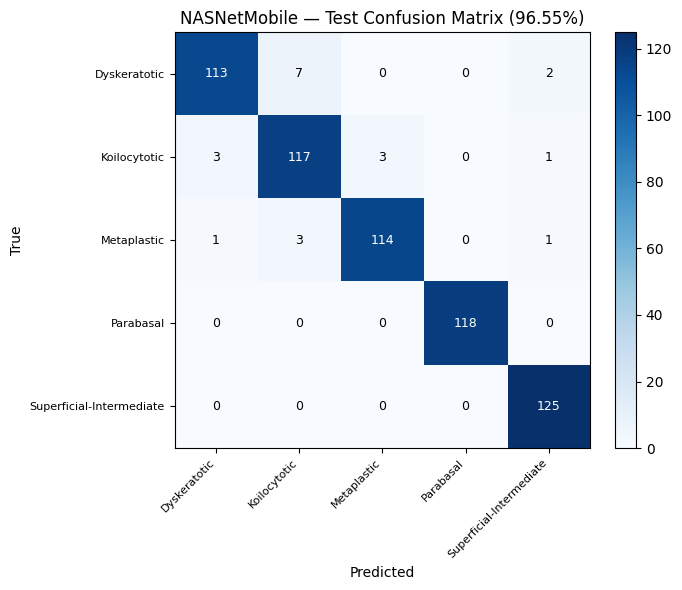

✅ NASNetMobile done in 38.7 min — Test 96.55%


########################################################################
#  [7/11]  ResNet50
########################################################################
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50  |  input (224, 224)  |  params 24,780,677
-- ResNet50 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - accuracy: 0.7861 - loss: 0.6093 - val_accuracy: 0.8816 - val_loss: 0.2987
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.8694 - loss: 0.3797 - val_accuracy: 0.9227 - val_loss: 0.1973
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - accuracy: 0.8818 - loss: 0.3343 - val_accuracy: 0.9211 - val_loss: 0.1878
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.8839 - loss: 0.3197 - val_accuracy: 0.9424 - val_loss: 0.1608
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - accuracy: 0.8952 - loss: 0.2921 - val_accuracy: 0.9507 - val_lo

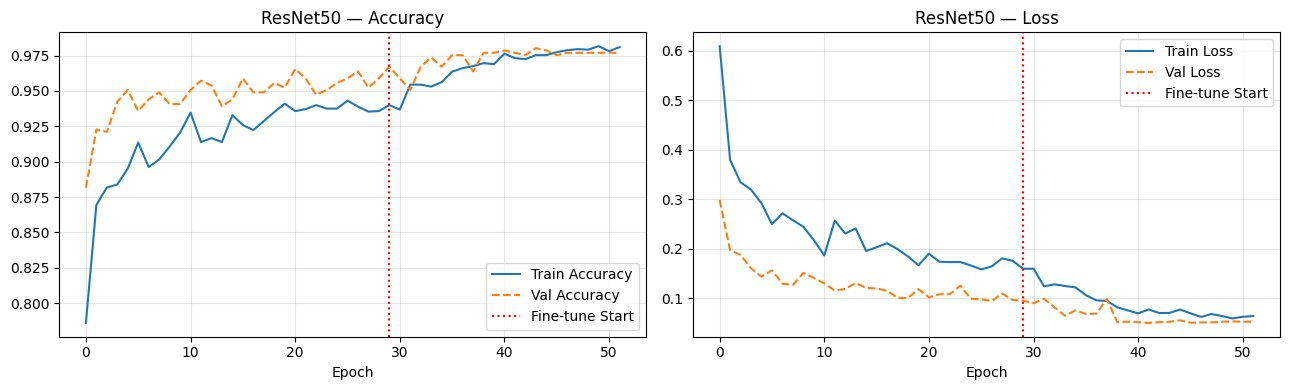

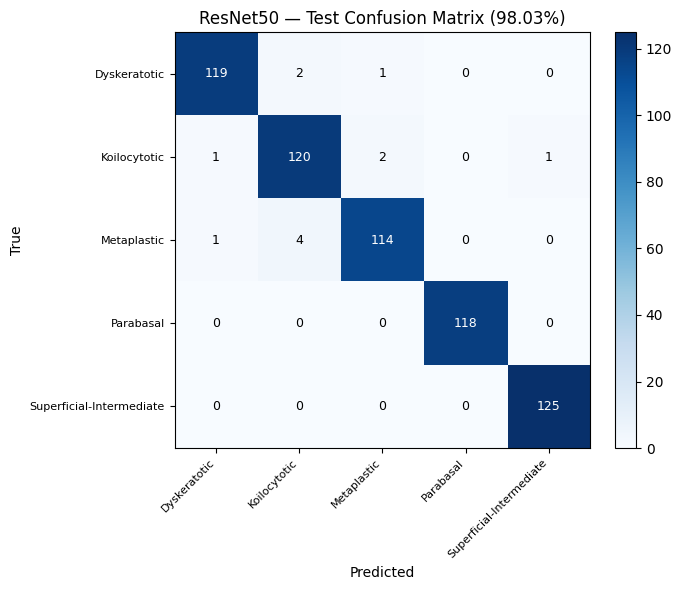

✅ ResNet50 done in 25.7 min — Test 98.03%


########################################################################
#  [8/11]  ResNet50V2
########################################################################
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50V2  |  input (224, 224)  |  params 24,757,765
-- ResNet50V2 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 45s 167ms/step - accuracy: 0.7444 - loss: 0.7491 - val_accuracy: 0.8701 - val_loss: 0.3583
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8263 - loss: 0.4933 - val_accuracy: 0.8602 - val_loss: 0.3431
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8440 - loss: 0.4318 - val_accuracy: 0.8799 - val_loss: 0.2974
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.8369 - loss: 0.4497 - val_accuracy: 0.8964 - val_loss: 0.2961
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.8567 - loss: 0.3893 - val_accuracy: 0.8931 - val_

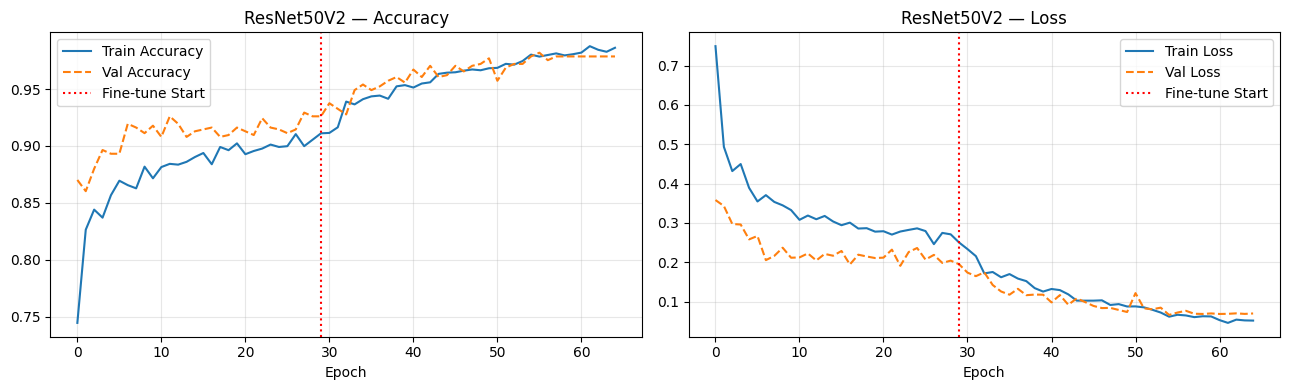

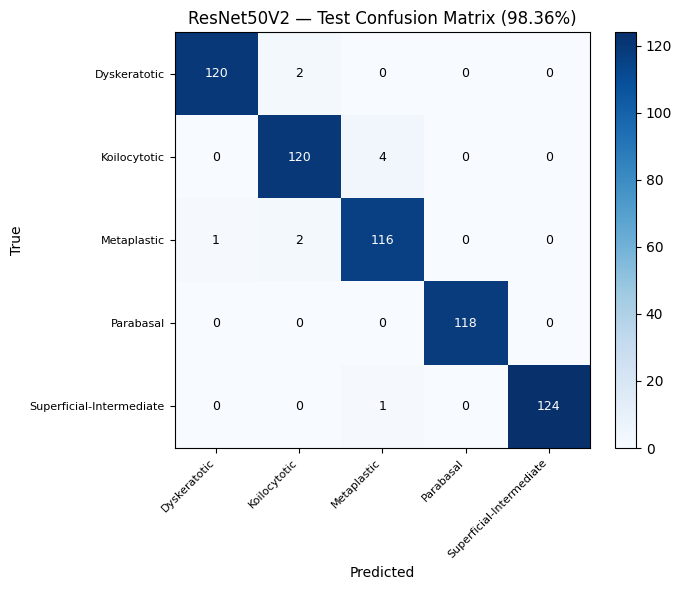

✅ ResNet50V2 done in 29.8 min — Test 98.36%


########################################################################
#  [9/11]  VGG16
########################################################################
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG16  |  input (224, 224)  |  params 15,115,077
-- VGG16 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.7349 - loss: 0.7762 - val_accuracy: 0.8882 - val_loss: 0.2918
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.8122 - loss: 0.5260 - val_accuracy: 0.8964 - val_loss: 0.3112
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 35s 199ms/step - accuracy: 0.8302 - loss: 0.4885 - val_accuracy: 0.9095 - val_loss: 0.2787
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 35s 195ms/step - accuracy: 0.8337 - loss: 0.4400 - val_accuracy: 0.9112 - val_loss: 0.2675
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.8546 - loss: 0.3896 - val_accuracy: 0.9194 - val_loss: 0.2404


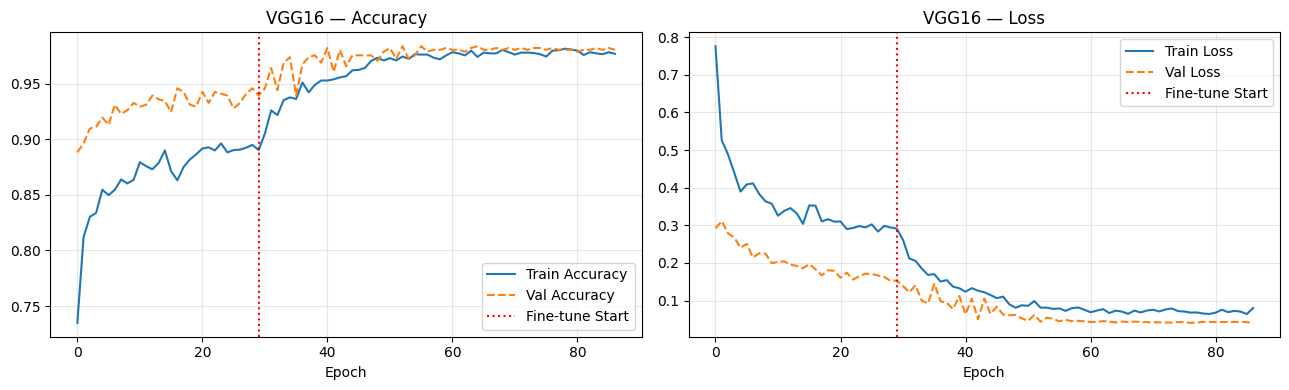

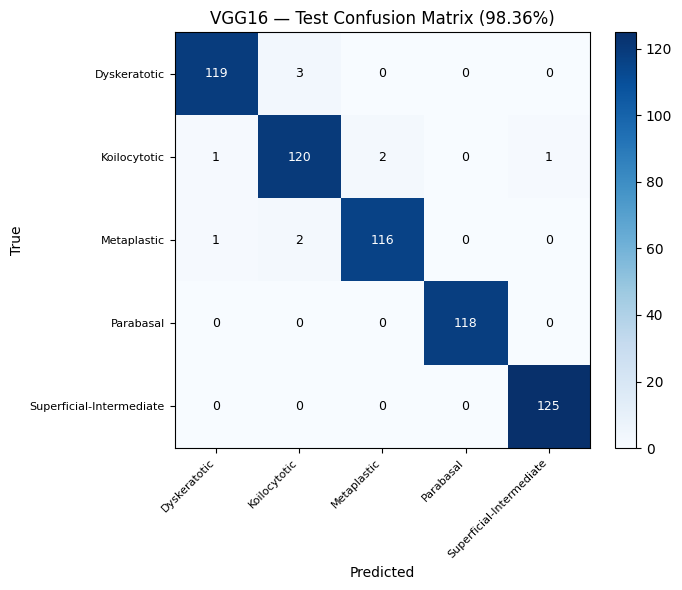

✅ VGG16 done in 71.3 min — Test 98.36%


########################################################################
#  [10/11]  VGG19
########################################################################
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG19  |  input (224, 224)  |  params 20,424,773
-- VGG19 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 53s 256ms/step - accuracy: 0.7413 - loss: 0.7455 - val_accuracy: 0.8997 - val_loss: 0.2848
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.8210 - loss: 0.5290 - val_accuracy: 0.8914 - val_loss: 0.2658
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.8313 - loss: 0.4686 - val_accuracy: 0.9030 - val_loss: 0.2569
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - accuracy: 0.8436 - loss: 0.4363 - val_accuracy: 0.9194 - val_loss: 0.2256
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.8355 - loss: 0.4510 - val_accuracy: 0.9194 - val_loss: 0.2067
Epoc

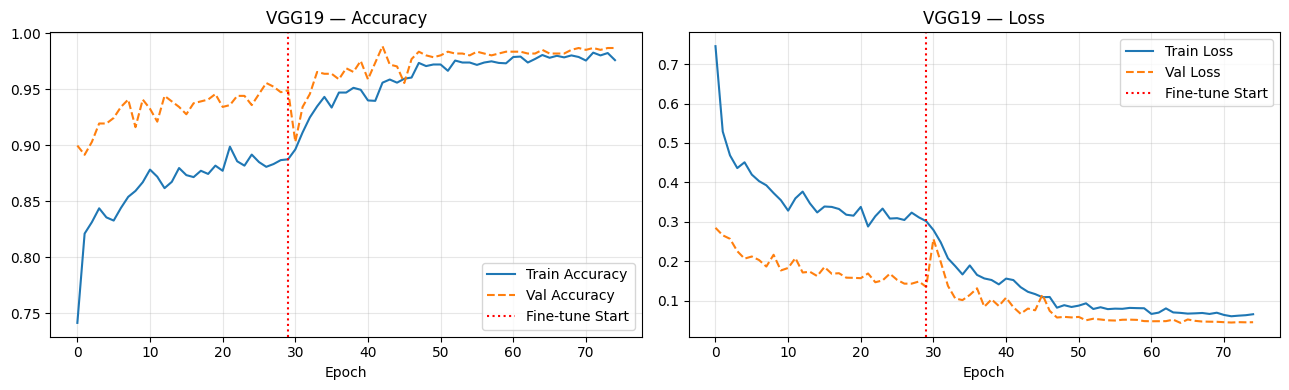

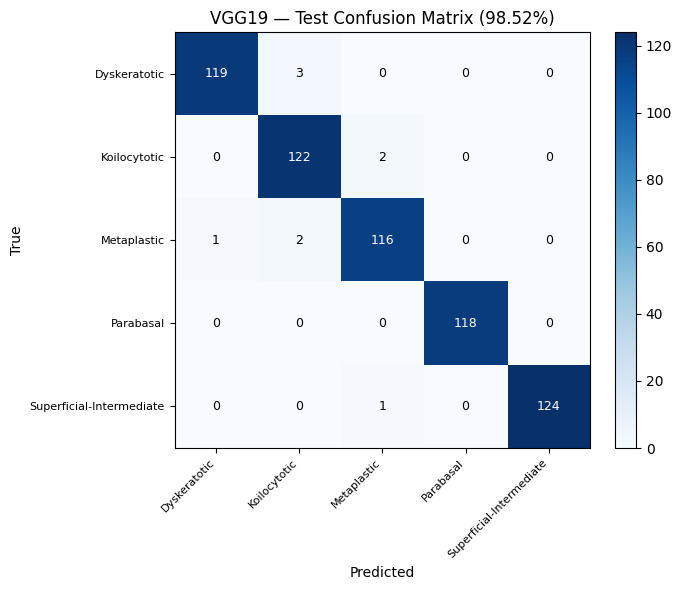

✅ VGG19 done in 73.6 min — Test 98.52%


########################################################################
#  [11/11]  Xception
########################################################################
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Xception  |  input (224, 224)  |  params 22,054,445
-- Xception Stage 1: head training --
Epoch 1/30


2026-10-04 22:44:58.405389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:44:58.559218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:44:59.867675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:00.010286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:00.995361: E external/local_xla/xla/stream_

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6345 - loss: 1.0758

2026-10-04 22:45:31.314033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:31.447261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:32.182543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:32.314809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:45:33.089789: E external/local_xla/xla/stream_

178/178 ━━━━━━━━━━━━━━━━━━━━ 70s 267ms/step - accuracy: 0.6964 - loss: 0.8972 - val_accuracy: 0.8059 - val_loss: 0.5540
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 133ms/step - accuracy: 0.7780 - loss: 0.6139 - val_accuracy: 0.8322 - val_loss: 0.4158
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.8006 - loss: 0.5280 - val_accuracy: 0.8635 - val_loss: 0.3490
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - accuracy: 0.8207 - loss: 0.4900 - val_accuracy: 0.8816 - val_loss: 0.3145
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.8277 - loss: 0.4708 - val_accuracy: 0.8964 - val_loss: 0.2940
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 133ms/step - accuracy: 0.8277 - loss: 0.4773 - val_accuracy: 0.9128 - val_loss: 0.2515
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 137ms/step - accuracy: 0.8267 - loss: 0.4629 - val_accuracy: 0.8865 - val_loss: 0.3053
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.8369 - loss: 0.4576 - val

...

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8676 - loss: 0.3649

2026-10-04 22:54:21.512295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 22:54:21.644435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


178/178 ━━━━━━━━━━━━━━━━━━━━ 85s 361ms/step - accuracy: 0.8729 - loss: 0.3440 - val_accuracy: 0.9227 - val_loss: 0.2058 - learning_rate: 1.0000e-05
Epoch 22/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 38s 214ms/step - accuracy: 0.9061 - loss: 0.2576 - val_accuracy: 0.9342 - val_loss: 0.1822 - learning_rate: 1.0000e-05
Epoch 23/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step - accuracy: 0.9075 - loss: 0.2550 - val_accuracy: 0.9342 - val_loss: 0.1687 - learning_rate: 1.0000e-05
Epoch 24/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 36s 202ms/step - accuracy: 0.9075 - loss: 0.2407 - val_accuracy: 0.9243 - val_loss: 0.1828 - learning_rate: 1.0000e-05
Epoch 25/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 37s 205ms/step - accuracy: 0.9107 - loss: 0.2272 - val_accuracy: 0.9507 - val_loss: 0.1610 - learning_rate: 1.0000e-05
Epoch 26/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.9269 - loss: 0.2071 - val_accuracy: 0.9490 - val_loss: 0.1592 - learning_rate: 1.0000e-05
Epoch 27/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 37s 2

2026-10-04 23:18:13.866243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 23:18:14.006938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 23:18:15.185440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 23:18:15.319694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 23:18:16.184587: E external/local_xla/xla/stream_

  Val TTA 97.53%  |  Test TTA 97.70% [96.38, 98.85]  |  no-TTA 97.04% (+0.66 pp)
  BalAcc 97.71%  kappa 0.9712  macroF1 0.9772  ECE 0.0223  abnormal→normal 0/246
                          precision    recall  f1-score   support

            Dyskeratotic     0.9748    0.9508    0.9627       122
            Koilocytotic     0.9375    0.9677    0.9524       124
             Metaplastic     0.9748    0.9748    0.9748       119
               Parabasal     1.0000    1.0000    1.0000       118
Superficial-Intermediate     1.0000    0.9920    0.9960       125

                accuracy                         0.9770       608
               macro avg     0.9774    0.9771    0.9772       608
            weighted avg     0.9773    0.9770    0.9770       608



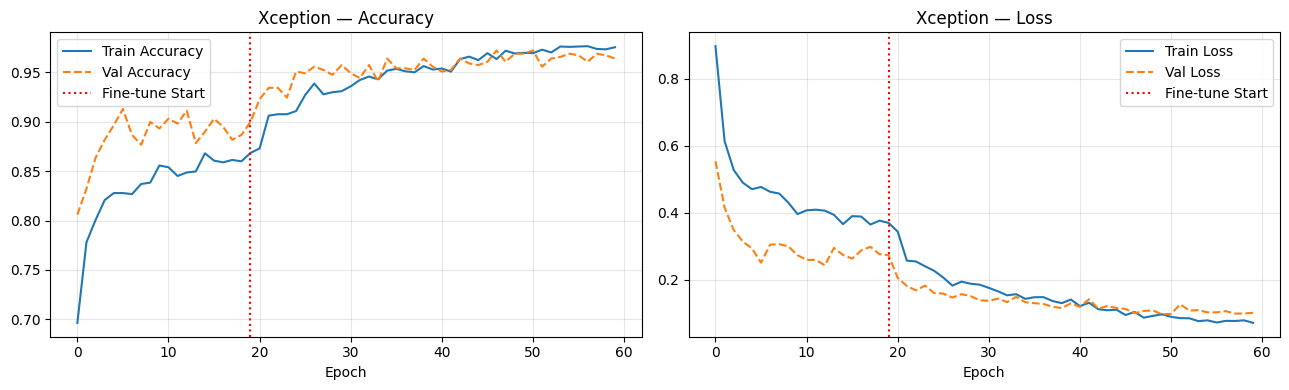

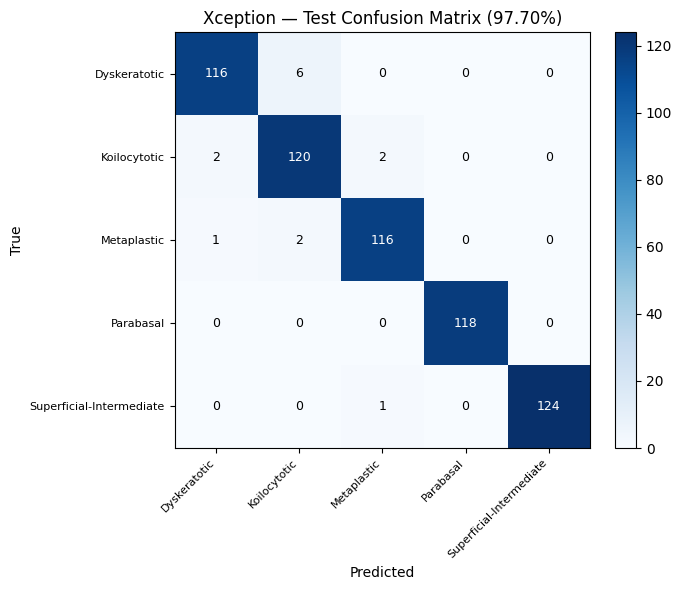

✅ Xception done in 35.6 min — Test 97.70%


SWEEP COMPLETE — 11 trained, 0 failed, 513.9 min total

-- Cross-backbone comparison --
            Model  Params(M) ImgSize  Val(%)  Test(%)  CI_lo(%)  CI_hi(%)  NoTTA(%)  TTA_delta(pp)  BalAcc(%)  Kappa  MacroF1  MeanConf    ECE  Abn2Norm  Ep_S1  Ep_S2  Runtime(min)
            VGG19      20.42 224x224   98.03    98.52     97.53     99.34     98.36           0.16      98.52 0.9815   0.9853    0.9794 0.0152         0     30     45          73.6
       ResNet50V2      24.76 224x224   98.36    98.36     97.20     99.34     97.86           0.49      98.36 0.9794   0.9836    0.9706 0.0136         0     30     35          29.8
            VGG16      15.12 224x224   98.19    98.36     97.37     99.34     98.19           0.16      98.36 0.9794   0.9836    0.9791 0.0125         1     30     57          71.3
         ResNet50      24.78 224x224   98.68    98.03     96.88     99.01     97.70           0.33      98.02 0.9753   0.9803    0.9782 0.0088  

/kaggle/working/sipakmed_backbone_benchmark.zip

/kaggle/working/sipakmed_backbone_benchmark_probs_reports.zip — 2.3 MB


/kaggle/working/sipakmed_backbone_benchmark_probs_reports.zip

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [LOOP] — RUN MANY BACKBONES BACK-TO-BACK
# Prerequisite: [CFG], [DATA-1], [DATA-2], [DATA-3] have been run once.
# This cell REPLACES [SELECT] → [SAVE]. Resumable: already-finished models are
# skipped, so after a Kaggle 12-h timeout you just re-run this cell.
# ════════════════════════════════════════════════════════════════════════════

import time, traceback

# MODELS_TO_RUN = [
#     'ResNet50', 'DenseNet201', 'InceptionV3', 'Xception', 'ConvNeXtTiny',
# ]
MODELS_TO_RUN = sorted(MODEL_ZOO)      # everything the environment exposes

SKIP_IF_DONE  = True      # skip a model whose .npz + meta.json already exist
STOP_ON_ERROR = False     # False -> log the failure and continue to the next
ZIP_AFTER_EACH = True     # re-archive after every model (timeout insurance)

COMP_CSV = f'{OUTPUT_DIR}/reports/model_comparison.csv'


# ── metric helpers (normally defined in [METRICS]) ───────────────────────────
def _ece(probs, y, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1); correct = (pred == y)
    edges = np.linspace(0.0, 1.0, n_bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        e += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(e)


def bootstrap_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed); n = len(y_true)
    accs = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.integers(0, n, n)
        accs[b] = np.mean(y_true[s] == y_pred[s])
    lo, hi = np.percentile(accs, [100*alpha/2, 100*(1-alpha/2)])
    return float(np.mean(y_true == y_pred)), float(lo), float(hi)


def plot_history(h1, h2, title, save_path):
    acc  = h1.history.get('accuracy', [])     + h2.history.get('accuracy', [])
    vacc = h1.history.get('val_accuracy', []) + h2.history.get('val_accuracy', [])
    los  = h1.history.get('loss', [])         + h2.history.get('loss', [])
    vlos = h1.history.get('val_loss', [])     + h2.history.get('val_loss', [])
    k = len(h1.epoch)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, m, v, lab in [(axes[0], acc, vacc, 'Accuracy'),
                          (axes[1], los, vlos, 'Loss')]:
        ax.plot(m, label=f'Train {lab}')
        ax.plot(v, label=f'Val {lab}', linestyle='--')
        ax.axvline(k-1, color='red', linestyle=':', label='Fine-tune Start')
        ax.set_title(f'{title} — {lab}'); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show(); plt.close()


# ── model factory (normally defined in [BUILD]) ──────────────────────────────
# Included here so the loop needs ONLY [CFG]→[DATA-3]; [SELECT] and [BUILD]
# stay available for single-model debugging but are not prerequisites.
def build_model(cfg, weights='imagenet'):
    base = cfg['builder'](weights, tuple(cfg['img_size']) + (3,))
    base.trainable = False
    inputs = layers.Input(shape=tuple(cfg['img_size']) + (3,))
    x = cfg['preprocess'](inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs, name=f'{cfg["slug"]}_clf')


def get_backbone(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise RuntimeError('No nested backbone Model found.')


def apply_finetune(base, cfg):
    base.trainable = True
    start = cfg.get('ft_start_layer')
    if start:
        assert start in [l.name for l in base.layers], \
            f"ft_start_layer '{start}' not in {cfg['app_name']}"
        on = False
        for l in base.layers:
            if l.name == start:
                on = True
            l.trainable = False if isinstance(l, layers.BatchNormalization) else on
    else:
        freeze_until = int(len(base.layers) * (1.0 - float(cfg.get('ft_fraction', 0.50))))
        for i, l in enumerate(base.layers):
            if i < freeze_until:
                l.trainable = False
            elif isinstance(l, layers.BatchNormalization):
                l.trainable = False
            else:
                l.trainable = True
    return sum(1 for l in base.layers if l.trainable), len(base.layers)


# ── per-model pipeline, rebuilt AFTER clear_session ──────────────────────────
# The augmentation and TTA layers are captured inside the tf.data map functions.
# Creating them here — after the session is cleared — is what makes it safe to
# clear the Keras graph between models, which is the only way GPU memory does
# not accumulate across a 20-backbone sweep.
def _fresh_pipeline(img_size):
    aug = models.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='shared_augmentation')
    fh = layers.RandomFlip('horizontal')
    fv = layers.RandomFlip('vertical')

    def _mk(images, labels, bs, shuffle=False, augment=False):
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        if tuple(img_size) != tuple(IMAGE_SIZE_DEFAULT):
            ds = ds.map(lambda x, y: (tf.image.resize(x, img_size), y),
                        num_parallel_calls=AUTOTUNE)
        if shuffle:
            ds = ds.shuffle(buffer_size=len(images), seed=SEED)
        if augment:
            ds = ds.map(lambda x, y: (aug(tf.expand_dims(x, 0), training=True)[0], y),
                        num_parallel_calls=AUTOTUNE)
        return ds.batch(bs).prefetch(AUTOTUNE)

    def _tta(mdl, dataset):
        out = []
        for images, _ in dataset:
            p = mdl.predict(images, verbose=0)
            if DETERMINISTIC_TTA:
                p += mdl.predict(tf.image.flip_left_right(images), verbose=0)
                p += mdl.predict(tf.image.flip_up_down(images),    verbose=0)
            else:
                p += mdl.predict(fh(images, training=True), verbose=0)
                p += mdl.predict(fv(images, training=True), verbose=0)
            p += mdl.predict(tf.image.rot90(images, k=1), verbose=0)
            p += mdl.predict(tf.image.rot90(images, k=3), verbose=0)
            out.extend(p / TTA_STEPS)
        return np.asarray(out)

    dsets = {
        'train'   : _mk(train_imgs, train_lbls, TRAIN_BATCH_SIZE,
                        shuffle=True, augment=True),
        'val'     : _mk(val_imgs,   val_lbls,   TRAIN_BATCH_SIZE),
        'val_eval': _mk(val_imgs,   val_lbls,   TTA_BATCH_SIZE),
        'test'    : _mk(test_imgs,  test_lbls,  TTA_BATCH_SIZE),
    }
    return dsets, _tta


def _append_comparison(row):
    comp = pd.read_csv(COMP_CSV) if os.path.exists(COMP_CSV) else pd.DataFrame()
    if len(comp) and 'Model' in comp.columns:
        comp = comp[comp['Model'] != row['Model']]
    comp = pd.concat([comp, pd.DataFrame([row])], ignore_index=True)
    comp = comp.sort_values('Test(%)', ascending=False).reset_index(drop=True)
    comp.to_csv(COMP_CSV, index=False)
    return comp


def _zip_outputs():
    full  = f'/kaggle/working/{OUTPUT_DIR}'
    light = f'/kaggle/working/{OUTPUT_DIR}_probs_reports'
    shutil.make_archive(full, 'zip', OUTPUT_DIR)
    tmp = '/kaggle/working/_light_pack'
    if os.path.exists(tmp):
        shutil.rmtree(tmp)
    os.makedirs(tmp, exist_ok=True)
    for sub in ['probs', 'reports', 'plots']:
        src = os.path.join(OUTPUT_DIR, sub)
        if os.path.exists(src):
            shutil.copytree(src, os.path.join(tmp, sub))
    shutil.make_archive(light, 'zip', tmp)
    shutil.rmtree(tmp)
    return full + '.zip', light + '.zip'


# ── one complete backbone: build -> stage1 -> stage2 -> TTA -> metrics -> save
def run_one(model_name):
    cfg  = MODEL_ZOO[model_name]
    slug = cfg['slug']
    img  = tuple(cfg['img_size'])
    s1   = f'{OUTPUT_DIR}/models/{slug}_stage1.keras'
    s2   = f'{OUTPUT_DIR}/models/{slug}_final.keras'
    npz  = f'{OUTPUT_DIR}/probs/{slug}_test_probabilities.npz'
    mj   = f'{OUTPUT_DIR}/reports/{slug}_meta.json'

    if SKIP_IF_DONE and os.path.exists(npz) and os.path.exists(mj):
        print(f'⏭  {model_name}: already done — skipped.')
        return None

    t0 = time.time()
    tf.keras.backend.clear_session()
    gc.collect()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    dsets, tta = _fresh_pipeline(img)

    mdl = build_model(cfg, weights='imagenet')
    mdl.compile(optimizer=tf.keras.optimizers.Adam(STAGE1_LR),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    total_param = int(mdl.count_params())
    print(f'\n{"="*72}\n{model_name}  |  input {img}  |  params {total_param:,}\n{"="*72}')

    print(f'-- {model_name} Stage 1: head training --')
    h1 = mdl.fit(dsets['train'], epochs=STAGE1_EPOCHS, validation_data=dsets['val'],
                 class_weight=cw_dict,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=STAGE1_PATIENCE,
                                          restore_best_weights=True),
                            ModelCheckpoint(s1, save_best_only=True, monitor='val_loss')])

    mdl.load_weights(s1)
    n_tr, n_tot = apply_finetune(get_backbone(mdl), cfg)
    mdl.compile(optimizer=tf.keras.optimizers.Adam(STAGE2_LR),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f'-- {model_name} Stage 2: fine-tune ({n_tr}/{n_tot} backbone layers) --')
    h2 = mdl.fit(dsets['train'], epochs=STAGE2_EPOCHS, initial_epoch=len(h1.epoch),
                 validation_data=dsets['val'], class_weight=cw_dict,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=STAGE2_PATIENCE,
                                          restore_best_weights=True),
                            ModelCheckpoint(s2, save_best_only=True, monitor='val_loss'),
                            ReduceLROnPlateau(monitor='val_loss', factor=RLROP_FACTOR,
                                              patience=RLROP_PATIENCE, min_lr=RLROP_MIN_LR)])

    # ── TTA inference ────────────────────────────────────────────────────────
    ev = build_model(cfg, weights=None)
    ev.load_weights(s2)
    P_test = tta(ev, dsets['test'])
    P_val  = tta(ev, dsets['val_eval'])
    plain  = (tf.data.Dataset.from_tensor_slices(test_imgs)
              .map(lambda x: tf.image.resize(x, img), num_parallel_calls=AUTOTUNE)
              .batch(TTA_BATCH_SIZE).prefetch(AUTOTUNE))
    P_noTTA = ev.predict(plain, verbose=0)

    for nm, P, n in [('P_test', P_test, len(y_test_true)),
                     ('P_val',  P_val,  len(y_val_true)),
                     ('P_noTTA', P_noTTA, len(y_test_true))]:
        assert P.shape == (n, NUM_CLASSES), f'{nm}: bad shape {P.shape}'
        assert np.allclose(P.sum(axis=1), 1.0, atol=1e-4), f'{nm}: rows not simplex'

    # ── metrics ──────────────────────────────────────────────────────────────
    preds     = np.argmax(P_test, axis=1)
    test_acc  = accuracy_score(y_test_true, preds)
    noTTA_acc = accuracy_score(y_test_true, np.argmax(P_noTTA, axis=1))
    val_acc   = accuracy_score(y_val_true,  np.argmax(P_val,   axis=1))
    bal_acc   = balanced_accuracy_score(y_test_true, preds)
    kappa     = cohen_kappa_score(y_test_true, preds)
    macro_f1  = f1_score(y_test_true, preds, average='macro')
    w_f1      = f1_score(y_test_true, preds, average='weighted')
    ece       = _ece(P_test, y_test_true)
    mean_conf = float(P_test.max(axis=1).mean())
    _, ci_lo, ci_hi = bootstrap_ci(y_test_true, preds)

    report_txt = classification_report(y_test_true, preds,
                                       target_names=CANONICAL_CLASSES,
                                       digits=4, zero_division=0)
    prec, rec, f1c, sup = precision_recall_fscore_support(
        y_test_true, preds, labels=range(NUM_CLASSES), zero_division=0)
    per_class_df = pd.DataFrame({'Class': CANONICAL_CLASSES, 'Precision': prec,
                                 'Recall': rec, 'F1': f1c, 'Support': sup})
    per_class_df.to_csv(f'{OUTPUT_DIR}/reports/{slug}_per_class.csv', index=False)

    cm = confusion_matrix(y_test_true, preds, labels=range(NUM_CLASSES))
    pd.DataFrame(cm, index=CANONICAL_CLASSES, columns=CANONICAL_CLASSES) \
      .to_csv(f'{OUTPUT_DIR}/reports/{slug}_confusion_matrix.csv')

    ABNORMAL = {CANONICAL_CLASSES.index(c) for c in CANONICAL_CLASSES
                if any(k in c.lower() for k in ['dysk', 'koil'])}
    NORMAL   = {CANONICAL_CLASSES.index(c) for c in CANONICAL_CLASSES
                if any(k in c.lower() for k in ['parabasal', 'superficial'])}
    abn2norm = int(sum(1 for t, p in zip(y_test_true, preds)
                       if t in ABNORMAL and p in NORMAL))
    n_abn    = int(sum(1 for t in y_test_true if t in ABNORMAL))

    print(f'  Val TTA {val_acc*100:.2f}%  |  Test TTA {test_acc*100:.2f}% '
          f'[{ci_lo*100:.2f}, {ci_hi*100:.2f}]  |  no-TTA {noTTA_acc*100:.2f}% '
          f'({(test_acc-noTTA_acc)*100:+.2f} pp)')
    print(f'  BalAcc {bal_acc*100:.2f}%  kappa {kappa:.4f}  macroF1 {macro_f1:.4f}  '
          f'ECE {ece:.4f}  abnormal→normal {abn2norm}/{n_abn}')
    print(report_txt)

    with open(f'{OUTPUT_DIR}/reports/{slug}_classification_report.txt', 'w') as f:
        f.write(f'{model_name} — SIPaKMeD 5-class held-out test\n' + '='*72 + '\n')
        f.write(f'seed={SEED} test={TEST_SIZE} val={VAL_SIZE} n_test={len(y_test_true)}\n')
        f.write(f'Accuracy {test_acc*100:.2f}%  CI [{ci_lo*100:.2f}, {ci_hi*100:.2f}]\n')
        f.write(f'BalAcc {bal_acc*100:.2f}%  kappa {kappa:.4f}  '
                f'macroF1 {macro_f1:.4f}  ECE {ece:.4f}\n')
        f.write(f'no-TTA {noTTA_acc*100:.2f}%  TTA {test_acc*100:.2f}%  '
                f'delta {(test_acc-noTTA_acc)*100:+.2f} pp\n')
        f.write(f'abnormal->normal FN: {abn2norm}/{n_abn}\n' + '-'*72 + '\n')
        f.write(report_txt + '\n' + '-'*72 + '\n')
        f.write(pd.DataFrame(cm, index=CANONICAL_CLASSES,
                             columns=CANONICAL_CLASSES).to_string() + '\n')

    # ── plots ────────────────────────────────────────────────────────────────
    plot_history(h1, h2, model_name, f'{OUTPUT_DIR}/plots/{slug}_training_history.png')
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CANONICAL_CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CANONICAL_CLASSES, fontsize=8)
    thr = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] > thr else 'black')
    ax.set_title(f'{model_name} — Test Confusion Matrix ({test_acc*100:.2f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plots/{slug}_confusion_matrix.png', dpi=150)
    plt.show(); plt.close()

    # ── persist ──────────────────────────────────────────────────────────────
    np.savez_compressed(npz, y_true=y_test_true, P_test=P_test,
                        P_test_noTTA=P_noTTA,
                        class_names=np.array(CANONICAL_CLASSES),
                        test_keys=np.array(test_filenames),
                        model_name=np.array([model_name]))
    np.savez_compressed(f'{OUTPUT_DIR}/probs/{slug}_val_probabilities.npz',
                        y_true=y_val_true, P_val=P_val,
                        class_names=np.array(CANONICAL_CLASSES),
                        val_keys=np.array(val_filenames),
                        model_name=np.array([model_name]))

    runtime = time.time() - t0
    meta = {
        'model_name': model_name, 'slug': slug, 'app_name': cfg['app_name'],
        'image_size': list(img), 'num_classes': NUM_CLASSES,
        'canonical_classes': CANONICAL_CLASSES, 'class_to_id': CLASS_TO_ID,
        'seed': SEED, 'test_size': TEST_SIZE, 'val_size': VAL_SIZE,
        'n_registry': int(n_common), 'n_train': int(len(idx_train)),
        'n_val': int(len(idx_val)), 'n_test': int(len(idx_test)),
        'unified_split': True, 'deterministic_tta': DETERMINISTIC_TTA,
        'tta_steps': TTA_STEPS, 'train_batch_size': TRAIN_BATCH_SIZE,
        'tta_batch_size': TTA_BATCH_SIZE, 'runtime_sec': round(runtime, 1),
        'stage1': {'epochs': STAGE1_EPOCHS, 'lr': STAGE1_LR,
                   'patience': STAGE1_PATIENCE, 'epochs_run': int(len(h1.epoch))},
        'stage2': {'epochs': STAGE2_EPOCHS, 'lr': STAGE2_LR,
                   'patience': STAGE2_PATIENCE, 'rlrop_factor': RLROP_FACTOR,
                   'rlrop_patience': RLROP_PATIENCE, 'min_lr': RLROP_MIN_LR,
                   'epochs_run': int(len(h2.epoch))},
        'finetune': {'start_layer': cfg['ft_start_layer'],
                     'fraction': cfg['ft_fraction'],
                     'unfrozen_layers': int(n_tr), 'backbone_layers': int(n_tot)},
        'total_params': total_param,
        'results': {'val_tta_acc': float(val_acc), 'test_tta_acc': float(test_acc),
                    'test_noTTA_acc': float(noTTA_acc),
                    'tta_delta_pp': float((test_acc - noTTA_acc) * 100),
                    'balanced_acc': float(bal_acc), 'kappa': float(kappa),
                    'macro_f1': float(macro_f1), 'weighted_f1': float(w_f1),
                    'mean_confidence': mean_conf, 'ece': float(ece),
                    'ci_lo': float(ci_lo), 'ci_hi': float(ci_hi),
                    'abnormal_to_normal': {'count': abn2norm, 'n_abnormal': n_abn}},
        'per_class': per_class_df.to_dict('records'),
        'confusion_matrix': cm.tolist(),
    }
    with open(mj, 'w') as f:
        json.dump(meta, f, indent=2)

    row = {
        'Model': model_name, 'Params(M)': round(total_param/1e6, 2),
        'ImgSize': f'{img[0]}x{img[1]}', 'Val(%)': round(val_acc*100, 2),
        'Test(%)': round(test_acc*100, 2), 'CI_lo(%)': round(ci_lo*100, 2),
        'CI_hi(%)': round(ci_hi*100, 2), 'NoTTA(%)': round(noTTA_acc*100, 2),
        'TTA_delta(pp)': round((test_acc-noTTA_acc)*100, 2),
        'BalAcc(%)': round(bal_acc*100, 2), 'Kappa': round(kappa, 4),
        'MacroF1': round(macro_f1, 4), 'MeanConf': round(mean_conf, 4),
        'ECE': round(ece, 4), 'Abn2Norm': abn2norm,
        'Ep_S1': int(len(h1.epoch)), 'Ep_S2': int(len(h2.epoch)),
        'Runtime(min)': round(runtime/60, 1),
    }
    _append_comparison(row)

    del mdl, ev, dsets, plain, h1, h2
    gc.collect()
    print(f'✅ {model_name} done in {runtime/60:.1f} min — Test {test_acc*100:.2f}%')
    return row


# ── THE LOOP ─────────────────────────────────────────────────────────────────
unknown = [m for m in MODELS_TO_RUN if m not in MODEL_ZOO]
assert not unknown, f'Not available in this environment: {unknown}'

done, failed = [], {}
t_all = time.time()
for i, name in enumerate(MODELS_TO_RUN, 1):
    print(f'\n\n{"#"*72}\n#  [{i}/{len(MODELS_TO_RUN)}]  {name}\n{"#"*72}')
    try:
        r = run_one(name)
        if r is not None:
            done.append(name)
            if ZIP_AFTER_EACH:
                _zip_outputs()
    except Exception as exc:
        failed[name] = f'{type(exc).__name__}: {exc}'
        print(f'❌ {name} FAILED — {failed[name]}')
        traceback.print_exc()
        tf.keras.backend.clear_session(); gc.collect()
        if STOP_ON_ERROR:
            raise

print(f'\n\n{"="*72}')
print(f'SWEEP COMPLETE — {len(done)} trained, {len(failed)} failed, '
      f'{(time.time()-t_all)/60:.1f} min total')
print('='*72)
if failed:
    for k, v in failed.items():
        print(f'  ❌ {k}: {v}')

if os.path.exists(COMP_CSV):
    print('\n-- Cross-backbone comparison --')
    print(pd.read_csv(COMP_CSV).to_string(index=False))

full_zip, light_zip = _zip_outputs()
for p in (full_zip, light_zip):
    print(f'{p} — {os.path.getsize(p)/1e6:.1f} MB')
    display(FileLink(p))


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [SELECT] — ◀◀◀  CHANGE THE BACKBONE HERE  ▶▶▶
# Re-run this cell and everything below it to benchmark a different architecture.
# Cells [CFG] through [DATA-3] do NOT need to be re-run.
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME = 'ResNet50'          # <-- any key printed by cell [CFG]

assert MODEL_NAME in MODEL_ZOO, (
    f"'{MODEL_NAME}' is not available. Choose one of: {sorted(MODEL_ZOO)}")

CFG        = MODEL_ZOO[MODEL_NAME]
SLUG       = CFG['slug']
IMAGE_SIZE = tuple(CFG['img_size'])

S1_FILE = f'{OUTPUT_DIR}/models/{SLUG}_stage1.keras'
S2_FILE = f'{OUTPUT_DIR}/models/{SLUG}_final.keras'

# Datasets at this backbone's native resolution (no-op when it is 224x224)
train_ds    = make_tf_dataset(train_imgs, train_lbls, TRAIN_BATCH_SIZE,
                              shuffle=True, augment=True, resize_to=IMAGE_SIZE)
val_ds      = make_tf_dataset(val_imgs,   val_lbls,   TRAIN_BATCH_SIZE,
                              resize_to=IMAGE_SIZE)
val_eval_ds = make_tf_dataset(val_imgs,   val_lbls,   TTA_BATCH_SIZE,
                              resize_to=IMAGE_SIZE)   # ordered, for TTA
test_ds     = make_tf_dataset(test_imgs,  test_lbls,  TTA_BATCH_SIZE,
                              resize_to=IMAGE_SIZE)   # ordered, for TTA

print('='*72)
print(f'SELECTED BACKBONE : {MODEL_NAME}')
print('='*72)
print(f'  slug            : {SLUG}')
print(f'  input size      : {IMAGE_SIZE}')
print(f'  preprocess_input: {getattr(CFG["preprocess"], "__module__", "identity")}')
print(f'  fine-tune from  : '
      + (f"layer '{CFG['ft_start_layer']}'" if CFG['ft_start_layer']
         else f"top {CFG['ft_fraction']*100:.0f}% of layers"))
print(f'  checkpoints     : {S1_FILE}\n                    {S2_FILE}')

SELECTED BACKBONE : ResNet50
  slug            : resnet50
  input size      : (224, 224)
  preprocess_input: keras.src.applications.resnet
  fine-tune from  : top 50% of layers
  checkpoints     : sipakmed_backbone_benchmark/models/resnet50_stage1.keras
                    sipakmed_backbone_benchmark/models/resnet50_final.keras


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [BUILD] — GENERIC TWO-STAGE TRANSFER-LEARNING MODEL
#
# Head is held CONSTANT across every backbone so that the comparison isolates
# representation quality rather than classifier capacity:
#   GAP -> BN -> Drop(0.5) -> Dense(512,relu) -> BN -> Drop(0.3)
#       -> Dense(256,relu) -> BN -> Dense(5,softmax)
# Global average pooling (Lin et al., 2013) rather than Flatten keeps the head
# parameter count independent of the backbone's final spatial grid, which is the
# only way a 7x7x512 VGG stack and a 7x7x2048 ResNet stack are comparable under
# an identical head budget.
# ════════════════════════════════════════════════════════════════════════════

def build_model(cfg, weights='imagenet'):
    base = cfg['builder'](weights, tuple(cfg['img_size']) + (3,))
    base.trainable = False

    inputs = layers.Input(shape=tuple(cfg['img_size']) + (3,))
    x = cfg['preprocess'](inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs, name=f'{cfg["slug"]}_clf')


def get_backbone(model):
    """Return the nested feature-extractor sub-model, whatever it is named."""
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise RuntimeError('No nested backbone Model found.')


def apply_finetune(base, cfg):
    """Stage-2 unfreezing policy. BatchNorm is ALWAYS left frozen: with 2833
    training images the batch statistics are too noisy to re-estimate, and
    unfreezing them is the single most common cause of fine-tuning collapse."""
    base.trainable = True
    start = cfg.get('ft_start_layer')
    if start:
        names = [l.name for l in base.layers]
        assert start in names, f"ft_start_layer '{start}' not in {cfg['app_name']}"
        on = False
        for l in base.layers:
            if l.name == start:
                on = True
            l.trainable = False if isinstance(l, layers.BatchNormalization) else on
    else:
        frac         = float(cfg.get('ft_fraction', 0.50))
        freeze_until = int(len(base.layers) * (1.0 - frac))
        for i, l in enumerate(base.layers):
            if i < freeze_until:
                l.trainable = False
            elif isinstance(l, layers.BatchNormalization):
                l.trainable = False
            else:
                l.trainable = True
    n_tr = sum(1 for l in base.layers if l.trainable)
    return n_tr, len(base.layers)


# Release the previous backbone's graph WITHOUT calling clear_session(): the
# augmentation and TTA layers created in [DATA-3] are captured inside the
# tf.data map functions, and clearing the global Keras state invalidates them.
for _v in ('model', 'eval_model', '_backbone', 'backbone'):
    if _v in globals():
        del globals()[_v]
gc.collect()

tf.random.set_seed(SEED)
np.random.seed(SEED)

model = build_model(CFG, weights='imagenet')
model.compile(optimizer=tf.keras.optimizers.Adam(STAGE1_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

_backbone   = get_backbone(model)
TOTAL_PARAM = int(model.count_params())
BASE_LAYERS = len(_backbone.layers)
print(f'{MODEL_NAME}: backbone layers={BASE_LAYERS}  total params={TOTAL_PARAM:,}')
print(f'Trainable params (Stage 1, head only): '
      f'{int(sum(np.prod(v.shape) for v in model.trainable_variables)):,}')

ResNet50: backbone layers=175  total params=24,780,677
Trainable params (Stage 1, head only): 1,187,333


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [STAGE-1] — FROZEN BACKBONE, HEAD TRAINING
# ════════════════════════════════════════════════════════════════════════════

print(f'-- {MODEL_NAME} Stage 1: head training --')
hist1 = model.fit(
    train_ds, epochs=STAGE1_EPOCHS, validation_data=val_ds, class_weight=cw_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=STAGE1_PATIENCE,
                             restore_best_weights=True),
               ModelCheckpoint(S1_FILE, save_best_only=True, monitor='val_loss')]
)

-- ResNet50 Stage 1: head training --
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 44s 165ms/step - accuracy: 0.7953 - loss: 0.6189 - val_accuracy: 0.9161 - val_loss: 0.2256
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.8683 - loss: 0.3630 - val_accuracy: 0.9161 - val_loss: 0.2122
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.8800 - loss: 0.3464 - val_accuracy: 0.9342 - val_loss: 0.1655
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.8867 - loss: 0.3124 - val_accuracy: 0.9194 - val_loss: 0.2083
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.8998 - loss: 0.2939 - val_accuracy: 0.9457 - val_loss: 0.1590
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.9022 - loss: 0.2745 - val_accuracy: 0.9375 - val_loss: 0.1564
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9001 - loss: 0.2715 - val_accuracy: 0.9539 - val_loss: 0.1235
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 22s 1

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [STAGE-2] — PARTIAL UNFREEZE + LOW-LR FINE-TUNE
# LR drops by two orders of magnitude (1e-3 -> 1e-5) before any pretrained
# weight is unfrozen; otherwise the first head-driven gradients destroy the
# ImageNet features they are supposed to adapt.
# ════════════════════════════════════════════════════════════════════════════

model.load_weights(S1_FILE)
backbone = get_backbone(model)
n_trainable, n_total = apply_finetune(backbone, CFG)
print(f'Unfrozen backbone layers: {n_trainable}/{n_total}')

model.compile(optimizer=tf.keras.optimizers.Adam(STAGE2_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(f'-- {MODEL_NAME} Stage 2: fine-tune --')
hist2 = model.fit(
    train_ds, epochs=STAGE2_EPOCHS, initial_epoch=len(hist1.epoch),
    validation_data=val_ds, class_weight=cw_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=STAGE2_PATIENCE,
                             restore_best_weights=True),
               ModelCheckpoint(S2_FILE, save_best_only=True, monitor='val_loss'),
               ReduceLROnPlateau(monitor='val_loss', factor=RLROP_FACTOR,
                                 patience=RLROP_PATIENCE, min_lr=RLROP_MIN_LR)]
)

Unfrozen backbone layers: 61/175
-- ResNet50 Stage 2: fine-tune --
Epoch 29/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 72s 260ms/step - accuracy: 0.9449 - loss: 0.1586 - val_accuracy: 0.9655 - val_loss: 0.1016 - learning_rate: 1.0000e-05
Epoch 30/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 32s 179ms/step - accuracy: 0.9400 - loss: 0.1598 - val_accuracy: 0.9622 - val_loss: 0.0951 - learning_rate: 1.0000e-05
Epoch 31/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 31s 176ms/step - accuracy: 0.9513 - loss: 0.1391 - val_accuracy: 0.9704 - val_loss: 0.0734 - learning_rate: 1.0000e-05
Epoch 32/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 31s 176ms/step - accuracy: 0.9552 - loss: 0.1250 - val_accuracy: 0.9688 - val_loss: 0.0728 - learning_rate: 1.0000e-05
Epoch 33/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9559 - loss: 0.1172 - val_accuracy: 0.9638 - val_loss: 0.0898 - learning_rate: 1.0000e-05
Epoch 34/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.9559 - loss: 0.1192 - val_accuracy: 0.9638 - val_loss: 0.

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [EVAL] — TTA INFERENCE ON VAL + TEST
# The val tensor is NOT optional: the downstream meta-ensemble must tune fusion
# weights on validation, never on the held-out test set.
# ════════════════════════════════════════════════════════════════════════════

eval_model = build_model(CFG, weights=None)
eval_model.load_weights(S2_FILE)

print(f'{MODEL_NAME} TTA evaluation...')
P_test = tta_predict(eval_model, test_ds)
P_val  = tta_predict(eval_model, val_eval_ds)

# Single deterministic forward pass, for the TTA ablation
test_ds_plain = (tf.data.Dataset.from_tensor_slices(test_imgs)
                 .map(lambda x: tf.image.resize(x, IMAGE_SIZE),
                      num_parallel_calls=AUTOTUNE)
                 .batch(TTA_BATCH_SIZE).prefetch(AUTOTUNE))
P_test_noTTA = eval_model.predict(test_ds_plain, verbose=0)

for nm, P, n in [('P_test', P_test, len(y_test_true)),
                 ('P_val',  P_val,  len(y_val_true)),
                 ('P_noTTA', P_test_noTTA, len(y_test_true))]:
    assert P.shape == (n, NUM_CLASSES), f'{nm}: bad shape {P.shape}'
    assert np.allclose(P.sum(axis=1), 1.0, atol=1e-4), f'{nm}: rows are not simplex'

test_acc  = accuracy_score(y_test_true, np.argmax(P_test,       axis=1))
noTTA_acc = accuracy_score(y_test_true, np.argmax(P_test_noTTA, axis=1))
val_acc   = accuracy_score(y_val_true,  np.argmax(P_val,        axis=1))
print(f'  Val  TTA Accuracy : {val_acc*100:.2f}%')
print(f'  Test TTA Accuracy : {test_acc*100:.2f}%')
print(f'  Test no-TTA       : {noTTA_acc*100:.2f}%   (delta {(test_acc-noTTA_acc)*100:+.2f} pp)')

ResNet50 TTA evaluation...
  Val  TTA Accuracy : 98.19%
  Test TTA Accuracy : 98.68%
  Test no-TTA       : 98.03%   (delta +0.66 pp)


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [METRICS] — FULL REPORT
#   * per-class precision / recall / F1
#   * balanced accuracy, Cohen's kappa
#   * Expected Calibration Error (Naeini et al., 2015) — a 98%-accurate model
#     that is 99.9% confident on its errors is unusable for triage
#   * 2000-resample bootstrap 95% CI — on n~608 the sampling noise is ~+/-1.5 pp,
#     so point estimates alone cannot separate backbones
#   * abnormal -> normal false negatives: the only error class with clinical cost
# ════════════════════════════════════════════════════════════════════════════

preds = np.argmax(P_test, axis=1)

bal_acc = balanced_accuracy_score(y_test_true, preds)
kappa   = cohen_kappa_score(y_test_true, preds)
macro_f1 = f1_score(y_test_true, preds, average='macro')
w_f1     = f1_score(y_test_true, preds, average='weighted')

def _ece(probs, y, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1); correct = (pred == y)
    edges = np.linspace(0.0, 1.0, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def bootstrap_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=SEED):
    rng  = np.random.default_rng(seed)
    n    = len(y_true)
    accs = np.empty(n_boot)
    for b in range(n_boot):
        s       = rng.integers(0, n, n)
        accs[b] = np.mean(y_true[s] == y_pred[s])
    lo, hi = np.percentile(accs, [100*alpha/2, 100*(1-alpha/2)])
    return float(np.mean(y_true == y_pred)), float(lo), float(hi)

ece       = _ece(P_test, y_test_true)
mean_conf = float(P_test.max(axis=1).mean())
acc_pt, ci_lo, ci_hi = bootstrap_ci(y_test_true, preds)

print('='*72)
print(f'{MODEL_NAME} — HELD-OUT TEST RESULTS  (n={len(y_test_true)})')
print('='*72)
print(f'  Accuracy           : {test_acc*100:.2f}%   95% CI [{ci_lo*100:.2f}, {ci_hi*100:.2f}]')
print(f'  Balanced Accuracy  : {bal_acc*100:.2f}%')
print(f"  Cohen's kappa      : {kappa:.4f}")
print(f'  Macro F1           : {macro_f1:.4f}')
print(f'  Weighted F1        : {w_f1:.4f}')
print(f'  Mean confidence    : {mean_conf:.4f}')
print(f'  ECE (15 bins)      : {ece:.4f}')
print()
report_txt = classification_report(y_test_true, preds,
                                   target_names=CANONICAL_CLASSES,
                                   digits=4, zero_division=0)
print(report_txt)

prec, rec, f1c, sup = precision_recall_fscore_support(
    y_test_true, preds, labels=range(NUM_CLASSES), zero_division=0)
per_class_df = pd.DataFrame({
    'Class'    : CANONICAL_CLASSES,
    'Precision': prec, 'Recall': rec, 'F1': f1c, 'Support': sup,
})
per_class_df.to_csv(f'{OUTPUT_DIR}/reports/{SLUG}_per_class.csv', index=False)

cm = confusion_matrix(y_test_true, preds, labels=range(NUM_CLASSES))
pd.DataFrame(cm, index=CANONICAL_CLASSES, columns=CANONICAL_CLASSES) \
  .to_csv(f'{OUTPUT_DIR}/reports/{SLUG}_confusion_matrix.csv')

# Clinically critical error direction
ABNORMAL = {CANONICAL_CLASSES.index(c) for c in CANONICAL_CLASSES
            if any(k in c.lower() for k in ['dysk', 'koil'])}
NORMAL   = {CANONICAL_CLASSES.index(c) for c in CANONICAL_CLASSES
            if any(k in c.lower() for k in ['parabasal', 'superficial'])}
abn2norm = int(sum(1 for t, p in zip(y_test_true, preds)
                   if t in ABNORMAL and p in NORMAL))
n_abn    = int(sum(1 for t in y_test_true if t in ABNORMAL))
print(f'CLINICALLY CRITICAL — abnormal predicted as normal: '
      f'{abn2norm}/{n_abn} ({abn2norm/max(n_abn,1)*100:.2f}%)')
print('(Invisible in aggregate accuracy; this is the false-negative rate that matters.)')

with open(f'{OUTPUT_DIR}/reports/{SLUG}_classification_report.txt', 'w') as f:
    f.write(f'{MODEL_NAME} — SIPaKMeD 5-class held-out test\n')
    f.write('='*72 + '\n')
    f.write(f'seed={SEED} test={TEST_SIZE} val={VAL_SIZE} n_test={len(y_test_true)}\n')
    f.write(f'Accuracy {test_acc*100:.2f}%  CI [{ci_lo*100:.2f}, {ci_hi*100:.2f}]\n')
    f.write(f'BalAcc {bal_acc*100:.2f}%  kappa {kappa:.4f}  '
            f'macroF1 {macro_f1:.4f}  ECE {ece:.4f}\n')
    f.write(f'no-TTA {noTTA_acc*100:.2f}%  TTA {test_acc*100:.2f}%  '
            f'delta {(test_acc-noTTA_acc)*100:+.2f} pp\n')
    f.write(f'abnormal->normal FN: {abn2norm}/{n_abn}\n')
    f.write('-'*72 + '\n')
    f.write(report_txt + '\n')
    f.write('-'*72 + '\n')
    f.write(pd.DataFrame(cm, index=CANONICAL_CLASSES,
                         columns=CANONICAL_CLASSES).to_string() + '\n')

ResNet50 — HELD-OUT TEST RESULTS  (n=608)
  Accuracy           : 98.68%   95% CI [97.70, 99.51]
  Balanced Accuracy  : 98.70%
  Cohen's kappa      : 0.9836
  Macro F1           : 0.9869
  Weighted F1        : 0.9868
  Mean confidence    : 0.9799
  ECE (15 bins)      : 0.0146

                          precision    recall  f1-score   support

            Dyskeratotic     0.9756    0.9836    0.9796       122
            Koilocytotic     0.9836    0.9677    0.9756       124
             Metaplastic     0.9752    0.9916    0.9833       119
               Parabasal     1.0000    1.0000    1.0000       118
Superficial-Intermediate     1.0000    0.9920    0.9960       125

                accuracy                         0.9868       608
               macro avg     0.9869    0.9870    0.9869       608
            weighted avg     0.9869    0.9868    0.9868       608

CLINICALLY CRITICAL — abnormal predicted as normal: 0/246 (0.00%)
(Invisible in aggregate accuracy; this is the false-negative

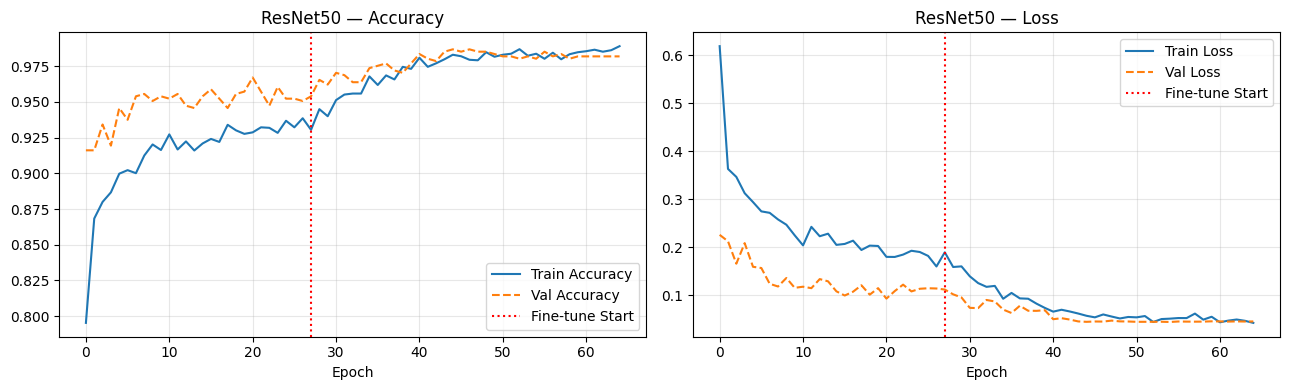

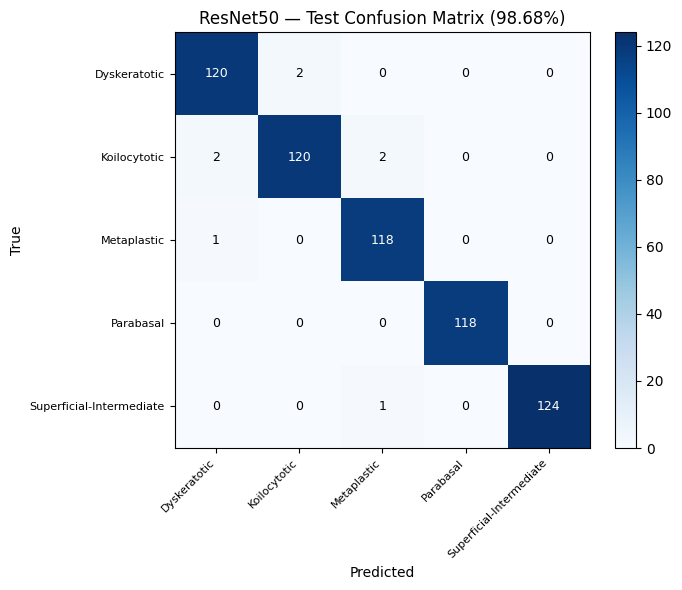

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [PLOTS] — TRAINING CURVES + CONFUSION MATRIX
# ════════════════════════════════════════════════════════════════════════════

def plot_history(h1, h2, title, save_path):
    acc      = h1.history.get('accuracy', [])     + h2.history.get('accuracy', [])
    val_acc_ = h1.history.get('val_accuracy', []) + h2.history.get('val_accuracy', [])
    loss     = h1.history.get('loss', [])         + h2.history.get('loss', [])
    val_loss = h1.history.get('val_loss', [])     + h2.history.get('val_loss', [])
    split    = len(h1.epoch)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, val_m, ylabel in [
        (axes[0], acc,  val_acc_, 'Accuracy'),
        (axes[1], loss, val_loss, 'Loss')
    ]:
        ax.plot(metric, label=f'Train {ylabel}')
        ax.plot(val_m,  label=f'Val {ylabel}', linestyle='--')
        ax.axvline(split-1, color='red', linestyle=':', label='Fine-tune Start')
        ax.set_title(f'{title} — {ylabel}')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show(); plt.close()

plot_history(hist1, hist2, MODEL_NAME,
             f'{OUTPUT_DIR}/plots/{SLUG}_training_history.png')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CANONICAL_CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CANONICAL_CLASSES, fontsize=8)
thresh = cm.max() / 2.0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                color='white' if cm[i, j] > thresh else 'black')
ax.set_title(f'{MODEL_NAME} — Test Confusion Matrix ({test_acc*100:.2f}%)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/{SLUG}_confusion_matrix.png', dpi=150)
plt.show(); plt.close()

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [SAVE] — PERSIST PROBABILITY TENSORS + METRICS + COMPARISON TABLE
# The .npz files are the real deliverable: they are the inputs to the separate
# meta-ensemble notebook. They carry test_keys/val_keys so row alignment can be
# re-verified there instead of assumed.
# ════════════════════════════════════════════════════════════════════════════

np.savez_compressed(
    f'{OUTPUT_DIR}/probs/{SLUG}_test_probabilities.npz',
    y_true      = y_test_true,
    P_test      = P_test,
    P_test_noTTA= P_test_noTTA,
    class_names = np.array(CANONICAL_CLASSES),
    test_keys   = np.array(test_filenames),
    model_name  = np.array([MODEL_NAME]),
)
np.savez_compressed(
    f'{OUTPUT_DIR}/probs/{SLUG}_val_probabilities.npz',
    y_true      = y_val_true,
    P_val       = P_val,
    class_names = np.array(CANONICAL_CLASSES),
    val_keys    = np.array(val_filenames),
    model_name  = np.array([MODEL_NAME]),
)

meta = {
    'model_name'        : MODEL_NAME,
    'slug'              : SLUG,
    'app_name'          : CFG['app_name'],
    'image_size'        : list(IMAGE_SIZE),
    'num_classes'       : NUM_CLASSES,
    'canonical_classes' : CANONICAL_CLASSES,
    'class_to_id'       : CLASS_TO_ID,
    'seed'              : SEED,
    'test_size'         : TEST_SIZE,
    'val_size'          : VAL_SIZE,
    'n_registry'        : int(n_common),
    'n_train'           : int(len(idx_train)),
    'n_val'             : int(len(idx_val)),
    'n_test'            : int(len(idx_test)),
    'unified_split'     : True,
    'deterministic_tta' : DETERMINISTIC_TTA,
    'tta_steps'         : TTA_STEPS,
    'train_batch_size'  : TRAIN_BATCH_SIZE,
    'tta_batch_size'    : TTA_BATCH_SIZE,
    'stage1'            : {'epochs': STAGE1_EPOCHS, 'lr': STAGE1_LR,
                           'patience': STAGE1_PATIENCE,
                           'epochs_run': int(len(hist1.epoch))},
    'stage2'            : {'epochs': STAGE2_EPOCHS, 'lr': STAGE2_LR,
                           'patience': STAGE2_PATIENCE,
                           'rlrop_factor': RLROP_FACTOR,
                           'rlrop_patience': RLROP_PATIENCE,
                           'min_lr': RLROP_MIN_LR,
                           'epochs_run': int(len(hist2.epoch))},
    'finetune'          : {'start_layer': CFG['ft_start_layer'],
                           'fraction': CFG['ft_fraction'],
                           'unfrozen_layers': int(n_trainable),
                           'backbone_layers': int(n_total)},
    'total_params'      : TOTAL_PARAM,
    'results'           : {
        'val_tta_acc'       : float(val_acc),
        'test_tta_acc'      : float(test_acc),
        'test_noTTA_acc'    : float(noTTA_acc),
        'tta_delta_pp'      : float((test_acc - noTTA_acc) * 100),
        'balanced_acc'      : float(bal_acc),
        'kappa'             : float(kappa),
        'macro_f1'          : float(macro_f1),
        'weighted_f1'       : float(w_f1),
        'mean_confidence'   : float(mean_conf),
        'ece'               : float(ece),
        'ci_lo'             : float(ci_lo),
        'ci_hi'             : float(ci_hi),
        'abnormal_to_normal': {'count': abn2norm, 'n_abnormal': n_abn},
    },
    'per_class'         : per_class_df.to_dict('records'),
    'confusion_matrix'  : cm.tolist(),
}
with open(f'{OUTPUT_DIR}/reports/{SLUG}_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

# ── Accumulating cross-backbone comparison table ─────────────────────────────
COMP_CSV = f'{OUTPUT_DIR}/reports/model_comparison.csv'
row = {
    'Model'        : MODEL_NAME,
    'Params(M)'    : round(TOTAL_PARAM / 1e6, 2),
    'ImgSize'      : f'{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}',
    'Val(%)'       : round(val_acc  * 100, 2),
    'Test(%)'      : round(test_acc * 100, 2),
    'CI_lo(%)'     : round(ci_lo    * 100, 2),
    'CI_hi(%)'     : round(ci_hi    * 100, 2),
    'NoTTA(%)'     : round(noTTA_acc* 100, 2),
    'TTA_delta(pp)': round((test_acc - noTTA_acc) * 100, 2),
    'BalAcc(%)'    : round(bal_acc  * 100, 2),
    'Kappa'        : round(kappa,  4),
    'MacroF1'      : round(macro_f1, 4),
    'MeanConf'     : round(mean_conf, 4),
    'ECE'          : round(ece, 4),
    'Abn2Norm'     : abn2norm,
    'Ep_S1'        : int(len(hist1.epoch)),
    'Ep_S2'        : int(len(hist2.epoch)),
}
comp = pd.read_csv(COMP_CSV) if os.path.exists(COMP_CSV) else pd.DataFrame()
if len(comp) and 'Model' in comp.columns:
    comp = comp[comp['Model'] != MODEL_NAME]
comp = pd.concat([comp, pd.DataFrame([row])], ignore_index=True)
comp = comp.sort_values('Test(%)', ascending=False).reset_index(drop=True)
comp.to_csv(COMP_CSV, index=False)

print('\n-- Cross-backbone comparison (all runs in this output dir) --')
print(comp.to_string(index=False))

files = {
    'Stage1 ckpt' : S1_FILE,
    'Final ckpt'  : S2_FILE,
    'Test probs'  : f'{OUTPUT_DIR}/probs/{SLUG}_test_probabilities.npz',
    'Val probs'   : f'{OUTPUT_DIR}/probs/{SLUG}_val_probabilities.npz',
    'Meta JSON'   : f'{OUTPUT_DIR}/reports/{SLUG}_meta.json',
    'Per-class'   : f'{OUTPUT_DIR}/reports/{SLUG}_per_class.csv',
    'Comparison'  : COMP_CSV,
}
print('\nFile Verification:')
for name, path in files.items():
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else 'MISSING'
    print(f'  {"✅" if exists else "❌"}  {name:<13} {size}')

print('\n' + '='*60)
print(f'🏆 {MODEL_NAME} COMPLETE — Test {test_acc*100:.2f}%')
print('='*60)
print('  ➡  Change MODEL_NAME in cell [SELECT] and re-run from there for the next backbone.')


-- Cross-backbone comparison (all runs in this output dir) --
            Model  Params(M) ImgSize  Val(%)  Test(%)  CI_lo(%)  CI_hi(%)  NoTTA(%)  TTA_delta(pp)  BalAcc(%)  Kappa  MacroF1  MeanConf    ECE  Abn2Norm  Ep_S1  Ep_S2  Runtime(min)
         ResNet50      24.78 224x224   98.19    98.68     97.70     99.51     98.03           0.66      98.70 0.9836   0.9869    0.9799 0.0146         0     28     37           NaN
            VGG19      20.42 224x224   98.03    98.52     97.53     99.34     98.36           0.16      98.52 0.9815   0.9853    0.9794 0.0152         0     30     45          73.6
       ResNet50V2      24.76 224x224   98.36    98.36     97.20     99.34     97.86           0.49      98.36 0.9794   0.9836    0.9706 0.0136         0     30     35          29.8
            VGG16      15.12 224x224   98.19    98.36     97.37     99.34     98.19           0.16      98.36 0.9794   0.9836    0.9791 0.0125         1     30     57          71.3
      InceptionV3      23.00 224

In [15]:
# ════════════════════════════════════════════════════════════════════════════
# CELL [ZIP] — ARCHIVE EVERYTHING FOR DOWNLOAD / LATER META-ENSEMBLE
# Safe to re-run after every backbone; the archive is rebuilt from the current
# contents of OUTPUT_DIR, so it always contains every completed run.
# ════════════════════════════════════════════════════════════════════════════

ARCHIVE_FULL  = f'/kaggle/working/{OUTPUT_DIR}'
ARCHIVE_PROBS = f'/kaggle/working/{OUTPUT_DIR}_probs_reports'

# 1) Full archive — includes model checkpoints (large)
shutil.make_archive(ARCHIVE_FULL, 'zip', OUTPUT_DIR)
print(f'{ARCHIVE_FULL}.zip — {os.path.getsize(ARCHIVE_FULL + ".zip")/1e6:.1f} MB')
display(FileLink(ARCHIVE_FULL + '.zip'))

# 2) Lightweight archive — probabilities + reports + plots only. This is the one
#    the meta-ensemble notebook actually needs.
_light = '/kaggle/working/_light_pack'
if os.path.exists(_light):
    shutil.rmtree(_light)
os.makedirs(_light, exist_ok=True)
for sub in ['probs', 'reports', 'plots']:
    src = os.path.join(OUTPUT_DIR, sub)
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(_light, sub))
shutil.make_archive(ARCHIVE_PROBS, 'zip', _light)
shutil.rmtree(_light)
print(f'{ARCHIVE_PROBS}.zip — {os.path.getsize(ARCHIVE_PROBS + ".zip")/1e6:.1f} MB')
display(FileLink(ARCHIVE_PROBS + '.zip'))

/kaggle/working/sipakmed_backbone_benchmark.zip — 5055.7 MB


/kaggle/working/sipakmed_backbone_benchmark.zip

/kaggle/working/sipakmed_backbone_benchmark_probs_reports.zip — 2.3 MB


/kaggle/working/sipakmed_backbone_benchmark_probs_reports.zip

---
## Loading these outputs in the meta-ensemble notebook

```python
import numpy as np, glob, os

probs = {}
for p in sorted(glob.glob('.../probs/*_test_probabilities.npz')):
    z    = np.load(p, allow_pickle=True)
    name = str(z['model_name'][0])
    probs[name] = {'P': z['P_test'], 'y': z['y_true'], 'keys': list(z['test_keys'])}

# Alignment is checkable, not assumed:
ref = list(probs.values())[0]['keys']
assert all(v['keys'] == ref for v in probs.values()), 'test key order differs'
```

Pair each with `*_val_probabilities.npz` and tune the fusion weights **on the
validation split only** — tuning on test is what turns a 0.3 pp "gain" into a
number that will not survive an external cohort.

**Two caveats worth carrying into the write-up**

1. With `n_test = 608`, the bootstrap 95% CI is roughly ±1.5 pp wide. Backbones
   separated by less than that are tied, not ranked. Report the intervals, and
   use McNemar on the paired predictions before claiming any backbone beats another.
2. Every backbone here shares one ImageNet initialisation lineage and one head.
   Their errors will be correlated, which caps how much the ensemble can gain —
   the ambiguity decomposition only pays out on genuine diversity. Expect the
   biggest fusion gains from architecturally distant pairs (e.g. ConvNeXt +
   DenseNet) rather than from near-siblings (ResNet50 + ResNet101).